## Описание проекта

**Цель проекта:** на основе выгруженных данных с маркетплейса  провести комплексный анализ бизнес-показателей за 2024 год, выявить нестандартные отклонения и предоставить рекомендации по фокусировке внимания. Во второй части проекта необходимо  провести A/B-тестирование, при котором тестовой группе будет предлагаться дополнительный бонус при первой покупке с целью увеличения конверсии пользователей.

В рамках проекта были решены следующие задачи:
- Первичный анализ и сбор данных, оценка качества данных
- Проведен обзор ключевых метрик
- Проведена оценка метрик монетизации и юнит-экономики
- Проведен поиск аномалий  и причины снижения выручки осенью 2024, сделаны выводы об эффективности маркетинговых инвестиций в разрезе каналов.
- Проанализированы результаты А/B эксперимента для тестирования конверсии пользователей из маркетингового канала TikTok.

## Описание данных

### Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

### Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

### Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


### Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |

### Описание событий в приложении

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


**Выручка маркетплейса** = 5% от total_price

## Загрузка и предобработка данных

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import MonthLocator, DateFormatter
import matplotlib.colors as mcolors
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [9]:
pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv')
pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv')
pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv')
pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv')

In [10]:
pa_marketplace_orders = pa_marketplace_orders.drop_duplicates()
pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.drop_duplicates()
pa_marketplace_users = pa_marketplace_users.drop_duplicates()
pa_marketplace_events = pa_marketplace_events.drop_duplicates()

dfs = [pa_marketplace_orders, pa_marketplace_campaign_costs, pa_marketplace_users, pa_marketplace_events]

for idx, df_clean in enumerate(dfs):
    print(f"\n--- DataFrame {idx + 1} ---")
    
    for column in df_clean.columns:
        if df_clean[column].dtype == 'object':
            unique_values = df_clean[column].unique()
            print(f'Уникальные значения в столбце "{column}": {len(unique_values)} значений')
            if len(unique_values) <= 10:
                print(f'  {unique_values}')
    
    print(df_clean.info())
    display(df_clean.head())



--- DataFrame 1 ---
Уникальные значения в столбце "order_date": 18009 значений
Уникальные значения в столбце "product_name": 200 значений
Уникальные значения в столбце "category_name": 25 значений
Уникальные значения в столбце "order_week": 53 значений
Уникальные значения в столбце "order_month": 12 значений
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       31357 non-null  int64  
 1   user_id        31357 non-null  int64  
 2   order_date     31357 non-null  object 
 3   product_name   31357 non-null  object 
 4   quantity       31357 non-null  int64  
 5   unit_price     31357 non-null  float64
 6   total_price    31357 non-null  float64
 7   category_name  31357 non-null  object 
 8   order_week     31357 non-null  object 
 9   order_month    31357 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



--- DataFrame 2 ---
Уникальные значения в столбце "acq_channel": 7 значений
  ['Affiliate' 'Direct' 'Email Marketing' 'Social Media' 'Google Ads' 'SEO'
 'TikTok']
Уникальные значения в столбце "spend_month": 13 значений
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     int64  
 1   acq_channel  88 non-null     object 
 2   spend_month  88 non-null     object 
 3   budget       88 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.9+ KB
None


,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750



--- DataFrame 3 ---
Уникальные значения в столбце "registration_date": 42318 значений
Уникальные значения в столбце "gender": 2 значений
  ['M' 'F']
Уникальные значения в столбце "region": 9 значений
  ['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская область' 'Новосибирск' 'Ростов-на-Дону']
Уникальные значения в столбце "acq_channel": 6 значений
  ['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']
Уникальные значения в столбце "buyer_segment": 4 значений
  ['regular' 'rare' 'one_time' 'medium']
Уникальные значения в столбце "cohort_week": 53 значений
Уникальные значения в столбце "cohort_month": 12 значений
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            44151 non-null  int64 
 1   registration_date  44151 non-null  object
 2   age  

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01



--- DataFrame 4 ---
Уникальные значения в столбце "event_date": 366 значений
Уникальные значения в столбце "event_type": 15 значений
Уникальные значения в столбце "os": 4 значений
  ['iOS' 'Windows' 'macOS' 'Android']
Уникальные значения в столбце "device": 3 значений
  ['mobile' 'desktop' 'tablet']
Уникальные значения в столбце "product_name": 201 значений
Уникальные значения в столбце "event_week": 53 значений
Уникальные значения в столбце "event_month": 12 значений
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   event_id      785859 non-null  int64 
 1   user_id       785859 non-null  int64 
 2   event_date    785859 non-null  object
 3   event_type    785859 non-null  object
 4   os            785859 non-null  object
 5   device        785859 non-null  object
 6   product_name  385740 non-null  object
 7   event_week    785859 non

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


## Обзор ключевых метрик

Ниже представлена общая динамика ключевых метрик: выручка и затраты, количество заказов и пользователей, ARPU и ARPPU, метрики активности пользователей (MAU, DAU), распределение количества заказов среди пользователей, сегментация пользователей по частоте покупок и Retention Rate по когортам пользователей. В конце блока описаны результаты и выводы.

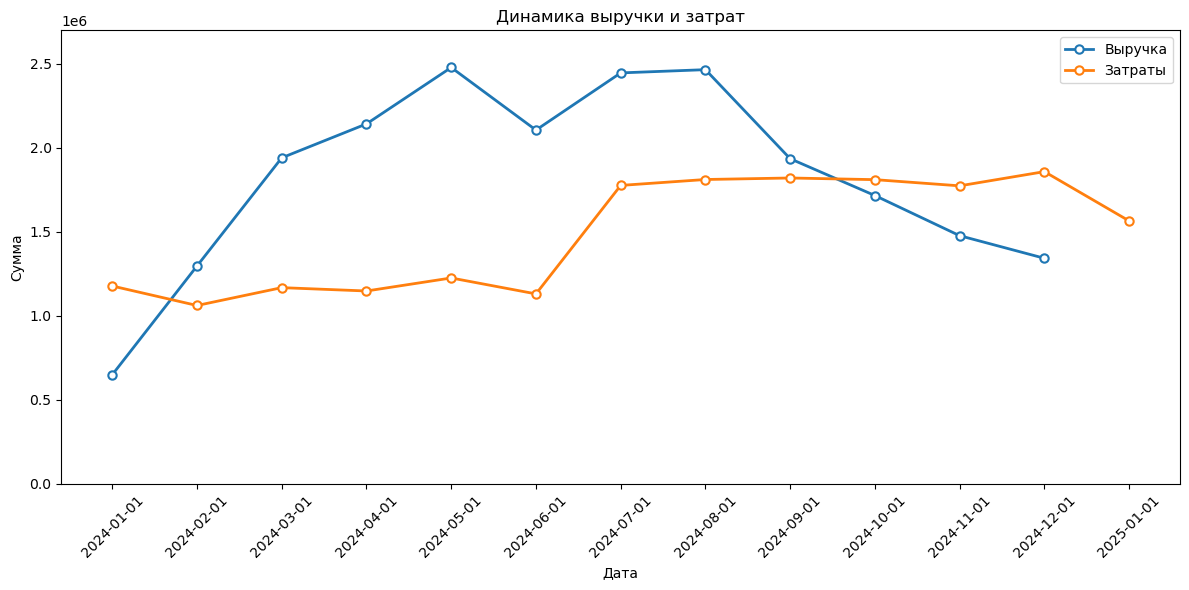

In [13]:
revenue = pa_marketplace_orders.groupby('order_month').agg(
    orders = ('order_id', 'nunique'),
    payers = ('user_id', 'nunique'),
    total_price = ('total_price', 'sum')
).reset_index()
revenue['revenue'] = revenue['total_price']*0.05
revenue = revenue.sort_values(by = 'order_month')
costs = pa_marketplace_campaign_costs.groupby('spend_month')['budget'].sum().reset_index()
costs = costs.sort_values(by = 'spend_month')

plt.figure(figsize=(12, 6))
plt.plot(revenue['order_month'], revenue['revenue'], label = 'Выручка', marker = 'o',
        markerfacecolor='white',       # белая заливка
         markeredgewidth=1.5,           # толщина обводки
         linewidth=2)        
plt.plot(costs['spend_month'], costs['budget'], label = 'Затраты', marker = 'o', 
         markerfacecolor='white',       # белая заливка
         markeredgewidth=1.5,           # толщина обводки
         linewidth=2)        
plt.title('Динамика выручки и затрат')
plt.xlabel('Дата')
plt.ylabel('Сумма')
plt.ylim(0,2700000)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
DAU = pa_marketplace_events.groupby('event_date')['user_id'].nunique().reset_index()
DAU = DAU.sort_values(by='event_date')

In [15]:
total_users = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index()
monthly_stat = pd.merge(total_users, revenue, how = 'left', left_on = 'event_month', right_on = 'order_month')
monthly_stat = pd.merge(monthly_stat, costs, how = 'left', left_on = 'event_month', right_on = 'spend_month') 
monthly_stat = monthly_stat.rename(columns = {'user_id':'mau'})
monthly_stat['arpu'] = monthly_stat['revenue']/monthly_stat['mau']
monthly_stat['arppu'] = monthly_stat['revenue']/monthly_stat['payers']
monthly_stat['AOV'] = monthly_stat['total_price']/monthly_stat['orders']
monthly_stat['CR'] = monthly_stat['payers']/monthly_stat['mau']*100
display(monthly_stat)

,event_month,mau,order_month,orders,payers,total_price,revenue,spend_month,budget,arpu,arppu,AOV,CR
0,2024-01-01,1149,2024-01-01,964,454,12977800.53,6.488900e+05,2024-01-01,1.177457e+06,564.743278,1429.273186,13462.448683,39.512620
1,2024-02-01,2162,2024-02-01,1917,839,25931140.19,1.296557e+06,2024-02-01,1.061386e+06,599.702595,1545.359964,13526.938023,38.806660
2,2024-03-01,2844,2024-03-01,2791,1165,38814995.89,1.940750e+06,2024-03-01,1.167680e+06,682.401475,1665.879652,13907.200247,40.963432
3,2024-04-01,3059,2024-04-01,3124,1324,42856767.90,2.142838e+06,2024-04-01,1.147740e+06,700.502908,1618.458002,13718.555666,43.282118
4,2024-05-01,3310,2024-05-01,3518,1404,49575162.02,2.478758e+06,2024-05-01,1.225322e+06,748.869517,1765.497223,14091.859585,42.416918
5,2024-06-01,3174,2024-06-01,3058,1230,42120237.13,2.106012e+06,2024-06-01,1.130440e+06,663.519804,1712.204761,13773.785850,38.752363
6,2024-07-01,3481,2024-07-01,3413,1385,48930709.06,2.446535e+06,2024-07-01,1.776447e+06,702.825468,1766.451591,14336.568725,39.787417
7,2024-08-01,3861,2024-08-01,3393,1385,49316047.93,2.465802e+06,2024-08-01,1.811678e+06,638.643459,1780.362741,14534.644247,35.871536
8,2024-09-01,3744,2024-09-01,2756,1163,38707333.94,1.935367e+06,2024-09-01,1.820719e+06,516.924866,1664.115819,14044.751067,31.063034
9,2024-10-01,3581,2024-10-01,2478,999,34322165.12,1.716108e+06,2024-10-01,1.810803e+06,479.225986,1717.826082,13850.752672,27.897235


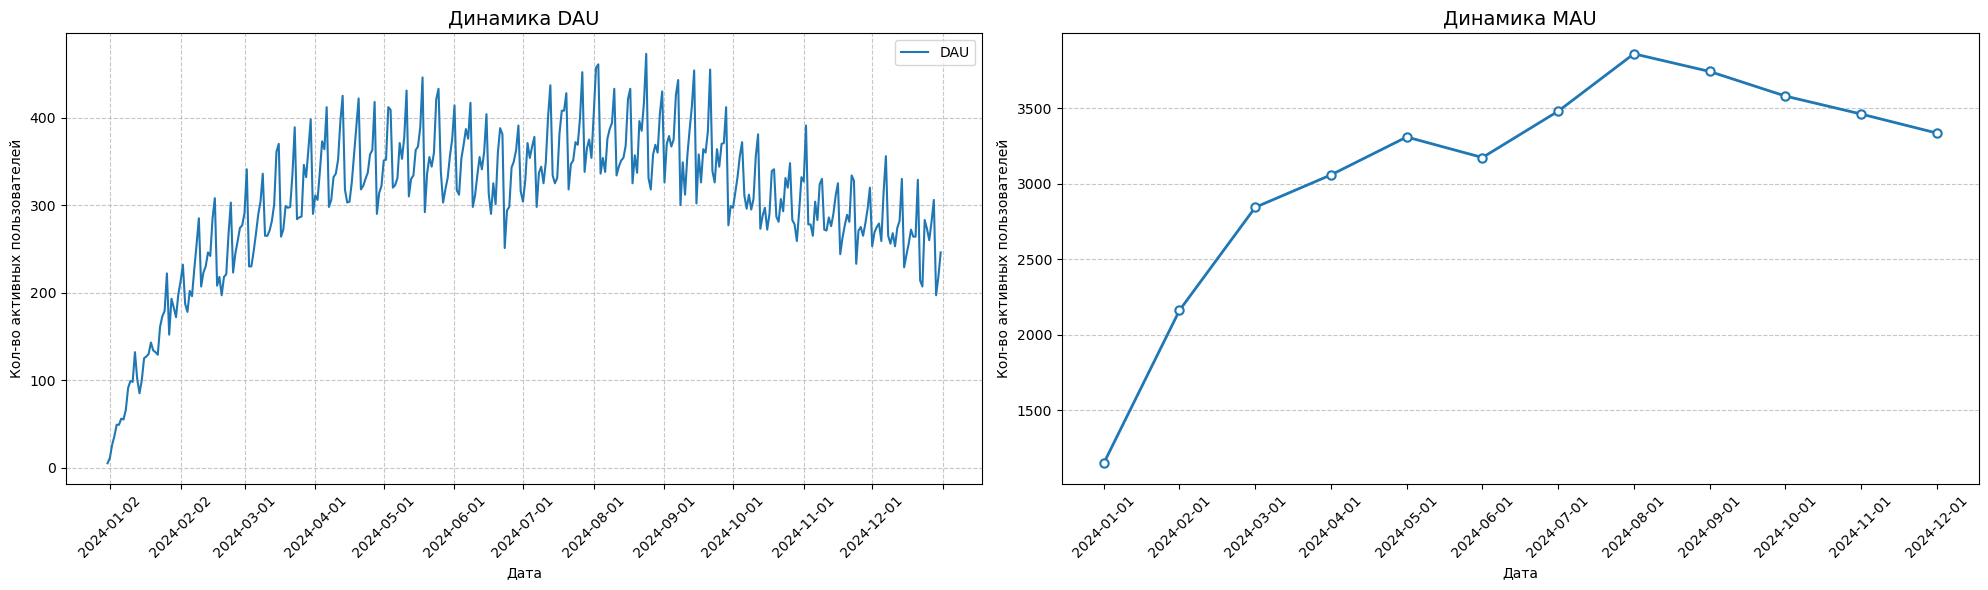

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Первый график - DAU
ax1.plot(DAU['event_date'], DAU['user_id'])
ax1.set_title('Динамика DAU', fontsize=14)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Кол-во активных пользователей')
ax1.xaxis.set_major_locator(MonthLocator(bymonthday=2))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(['DAU'])
ax1.grid(linestyle='--', alpha=0.7)

# Второй график - MAU
ax2.plot(monthly_stat['event_month'], monthly_stat['mau'], marker='o',
         markerfacecolor='white',
         markeredgewidth=1.5,
         linewidth=2)
ax2.set_title('Динамика MAU', fontsize=14)
ax2.set_xlabel('Дата')
ax2.set_ylabel('Кол-во активных пользователей')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

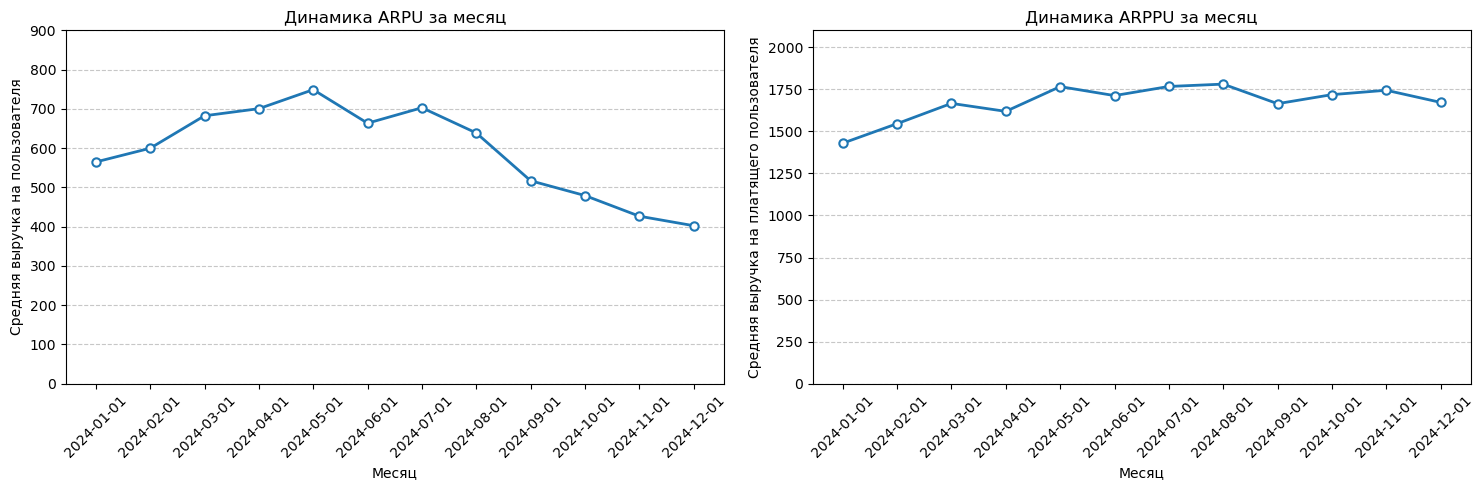

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(monthly_stat['event_month'], monthly_stat['arpu'],
         marker='o',                    
         markerfacecolor='white',       
         markeredgewidth=1.5,           
         linewidth=2)   
plt.title('Динамика ARPU за месяц')
plt.xlabel('Месяц')
plt.ylabel('Средняя выручка на пользователя')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.ylim(0, 900)

plt.subplot(1, 2, 2)
plt.plot(monthly_stat['event_month'], monthly_stat['arppu'],
         marker='o',                    
         markerfacecolor='white',       
         markeredgewidth=1.5,           
         linewidth=2)   
plt.title('Динамика ARPPU за месяц')
plt.xlabel('Месяц')
plt.ylabel('Средняя выручка на платящего пользователя')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.ylim(0, 2100)

plt.tight_layout()
plt.show()


In [18]:
print('Активных пользователей:', pa_marketplace_events['user_id'].nunique())
print('Покупателей:', pa_marketplace_orders['user_id'].nunique())
print('Зарегистрированных пользователей: ', pa_marketplace_users['user_id'].nunique())

unregistered_active_users = pa_marketplace_events[
    ~pa_marketplace_events['user_id'].isin(pa_marketplace_users['user_id'])
]['user_id'].nunique()

unregistered_payers = pa_marketplace_orders[
    ~pa_marketplace_orders['user_id'].isin(pa_marketplace_users['user_id'])
]['user_id'].nunique()

print('Количество незарегистрированных активных пользователей:', unregistered_active_users)
print('Количество незарегистрированных покупателей:', unregistered_payers)
set_unreg_payers = pa_marketplace_orders[
    ~pa_marketplace_orders['user_id'].isin(pa_marketplace_users['user_id'])
]['user_id'].unique()

unreg_series = pd.Series(set_unreg_payers)
in_events_mask = unreg_series.isin(pa_marketplace_events['user_id'])

print("Незарегистрированные покупатели в событиях:")
print(unreg_series[in_events_mask].count())


Активных пользователей: 22138
Покупателей: 8922
Зарегистрированных пользователей:  44151
Количество незарегистрированных активных пользователей: 536
Количество незарегистрированных покупателей: 268
Незарегистрированные покупатели в событиях:
228


Таблицы с данными по событиям и заказам содержат менее 3% пользователей, про которых нет данных в таблице с зарегистрированными пользователями. Вероятнее всего, это пользователи, у которых регистрация произошла раньше 01-01-2024, и при фильтрации таблицы с пользователями информация об этих user_id была потеряна. Так как эти пользователи скорее всего были привлечены до 01-01-2024, информацию про их действия  учитывать не стоит. Таким образом, оставляем только пользователей, для которых известна принадежность  к когортам.

In [20]:
pa_marketplace_events = pd.merge(pa_marketplace_events, pa_marketplace_users[['user_id','cohort_month']], how = 'inner', on ='user_id' )
pa_marketplace_orders = pd.merge(pa_marketplace_orders, pa_marketplace_users[['user_id','cohort_month']], how = 'inner', on ='user_id' )
pa_marketplace_events['first_event'] = pa_marketplace_events.groupby('user_id')['event_date'].transform('min')
pa_marketplace_events['first_event'] = pd.to_datetime(pa_marketplace_events['first_event']).dt.to_period('M').dt.to_timestamp()
pa_marketplace_orders['first_event'] = pa_marketplace_orders.groupby('user_id')['order_date'].transform('min')
pa_marketplace_orders['first_event'] = pd.to_datetime(pa_marketplace_orders['first_event']).dt.to_period('M').dt.to_timestamp()


In [21]:
pa_marketplace_events['event_month'] = pd.to_datetime(pa_marketplace_events['event_month'])
pa_marketplace_events['cohort_month'] = pd.to_datetime(pa_marketplace_events['cohort_month'])
pa_marketplace_orders['order_month'] = pd.to_datetime(pa_marketplace_orders['order_month'])
pa_marketplace_orders['cohort_month'] = pd.to_datetime(pa_marketplace_orders['cohort_month'])

print('Пользователей, для которых есть events раньше, чем cohort_month:',
      pa_marketplace_events[pa_marketplace_events['first_event'] < pa_marketplace_events['cohort_month']]['user_id'].nunique())

print('Пользователей, для которых есть orders раньше, чем cohort_month:',
      pa_marketplace_orders[pa_marketplace_orders['first_event'] < pa_marketplace_orders['cohort_month']]['user_id'].nunique())
users_count = pa_marketplace_orders.groupby('user_id')['order_id'].count()
print('Среднее количество заказов на пользователя:', users_count.mean())

Пользователей, для которых есть events раньше, чем cohort_month: 0
Пользователей, для которых есть orders раньше, чем cohort_month: 0
Среднее количество заказов на пользователя: 3.518141899699561


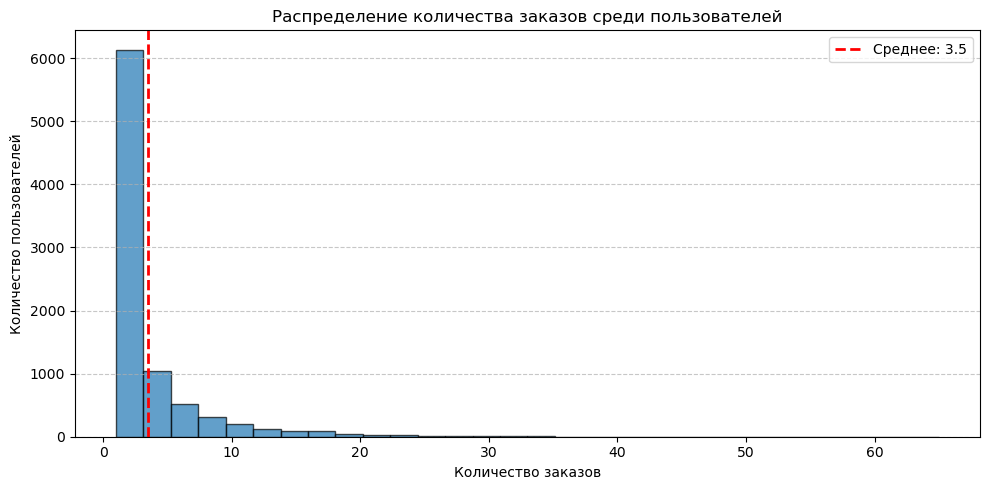

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(users_count, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(x=users_count.mean(), color='r', linestyle='--', linewidth=2, label=f'Среднее: {users_count.mean():.1f}')
plt.title('Распределение количества заказов среди пользователей')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

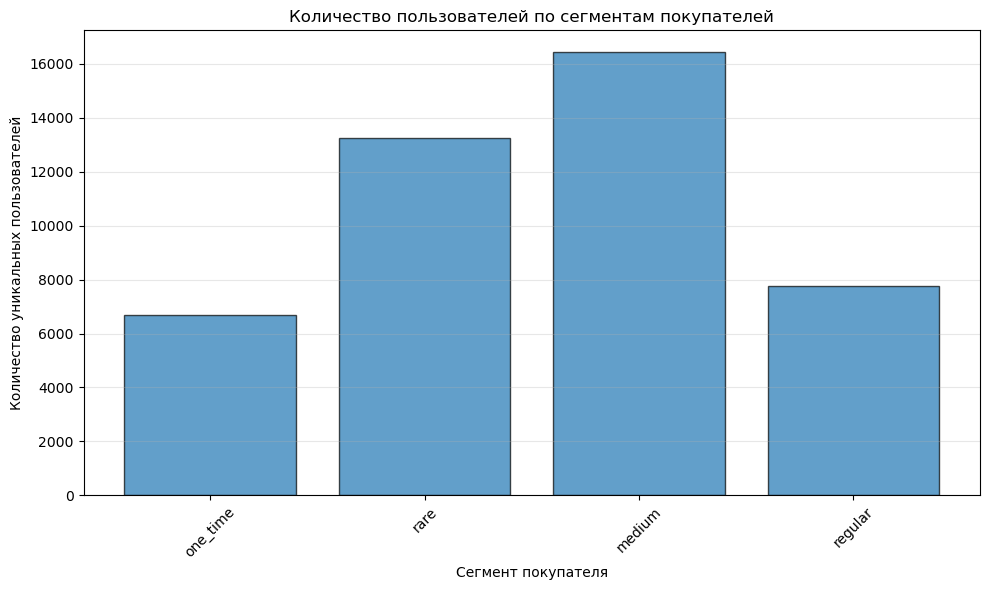

In [23]:
user_counts = pa_marketplace_users.groupby('buyer_segment')['user_id'].nunique()
correct_order = ['one_time', 'rare', 'medium', 'regular']

user_counts_ordered = user_counts.reindex(correct_order)

plt.figure(figsize=(10, 6))
plt.bar(user_counts_ordered.index, user_counts_ordered.values, 
        edgecolor='k', alpha=0.7)

plt.title('Количество пользователей по сегментам покупателей')
plt.xlabel('Сегмент покупателя')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

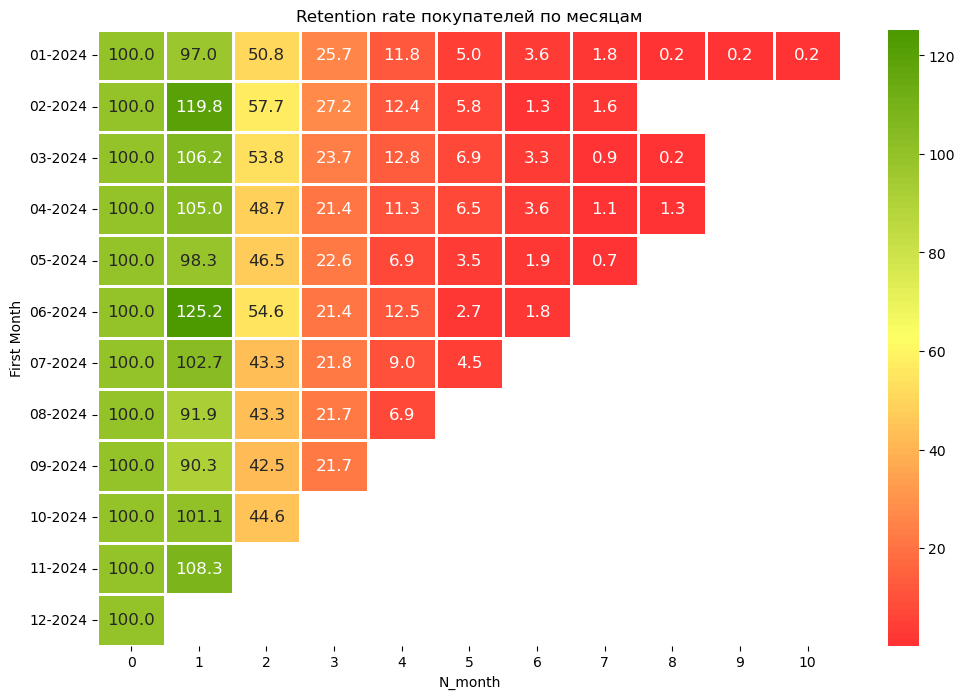

In [24]:
pa_marketplace_orders['period'] = (pa_marketplace_orders['order_month'].dt.to_period('M').astype('int64') - 
                                   pa_marketplace_orders['cohort_month'].dt.to_period('M').astype('int64'))
rr_orders = pa_marketplace_orders.pivot_table(
        index='cohort_month',
        columns='period',
        values='user_id',
        aggfunc='nunique',
        fill_value=0
    )
rr_orders = (rr_orders.divide(rr_orders[0], axis=0) * 100).round(2)

rr_orders[rr_orders == 0] = float('nan')
rr_orders.index = rr_orders.index.strftime('%m-%Y')  

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

plt.figure(figsize=(12, 8))
sns.heatmap(rr_orders,
           cmap=cmap,
           annot=True,
           fmt='.1f',
           linewidths=2,
           annot_kws={"size": 12})

plt.title('Retention rate покупателей по месяцам')
plt.xlabel('N_month')
plt.ylabel('First Month')
plt.show()


- В 2024 году в сервис было привлечено 22138 пользователей, из которых 8922 в итоге совершили хотя бы один заказ. 
- Выручка сервиса росла с 0.65 млн в январе 2024 до 2.5 млн в мае 2024, затем, летом не было сильных изменений в выручке, а с осени началось сильное снижение выручки, которое продолжилось до конца года. В декабре выручка составила 1.3 млн. Маркетинговый бюджет в первой половине года не имел сильных изменений и варьировал около 1.1-1.2 млн, затем в июле 2024 года маркетнговый бюджет был увеличен до 1.8 млн. и данный ежемесячный объем бюджета сохранялся до конца года.
- Активность аудитории (DAU, MAU) маркетплейса росла с начала года до августа, с небольшим снижением метрик в июне. Максимальное количество пользователей было достигнуто в августе - сервис посетил 3861 человек. Затем активность аудитории постепенно снижалась, в декабре MAU составило 3336 человек. Негативный тренд с середины года к концу показывают метрики, напрямую связанные с доходностью бизнеса: количество заказов, доля пользователей, совершающих заказы, ARPU.
- В совокупности с тем, что значения среднего чека заказа и ARPPU оставались стабильными весь год, данные говорят о том, что начиная с июля-августа, произошли какие-то серьезные изменения в маркетинговой стратегии. Несмотря на значительное увеличение маркетингового бюджета, эти изменения привели к тому, что в сервис началось привлечение большой части нецелевой аудитории, которая не была заинтересована в покупках на маркетплейсе. 
- Среднее количество заказов на пользователя составило 3.5 заказа/чел. Подавляющее большинство пользователей делает небольшое количество заказов (1-3). Retention rate имеет высокие значения только во втором месяце жизни когорты, после чего резко уменьшается. Только около 20-25% привлеченных пользователей делают покупки чере 3 месяца после регистрации. Необходимо обратить внимание на возвращаемость клиентов в сервис и проанализировать причины высокого оттока пользователей.

## Оценка метрик монетизации и юнит-экономики

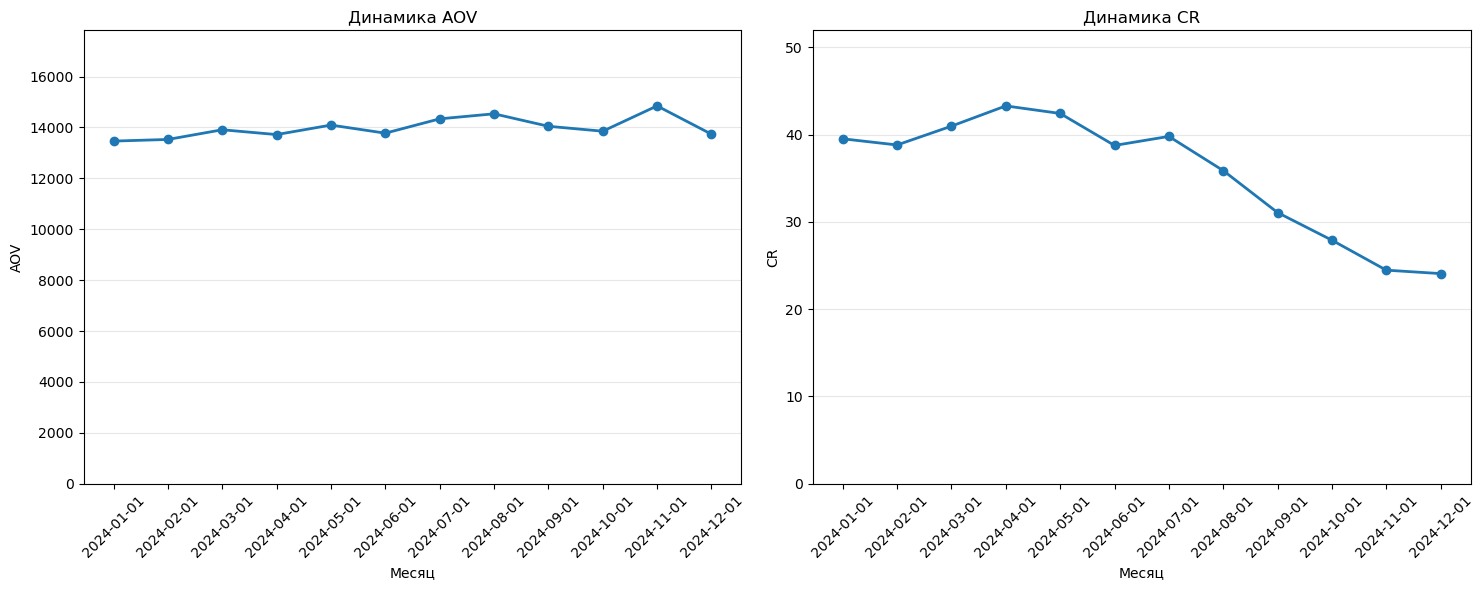

In [27]:
business_metrics = ['AOV','CR']
plt.figure(figsize=(15, 6))
    
for i, metric in enumerate(business_metrics):
    plt.subplot(1, 2, i+1)
    plt.plot(monthly_stat['event_month'], monthly_stat[metric], marker='o', linewidth=2)
    plt.title(f'Динамика {metric.upper()}')
    plt.xlabel('Месяц')  
    plt.ylabel(metric.upper())
    plt.grid(axis='y', alpha=0.3)
    
    y_max = monthly_stat[metric].max()
    plt.ylim(0, y_max * 1.2)
    
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
payers_id = pa_marketplace_orders['user_id'].unique()
pa_marketplace_users['payer_flag'] = pa_marketplace_users['user_id'].isin(payers_id).astype(int)

In [29]:
monthly_cohorts = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index()
monthly_cohorts = monthly_cohorts.rename (columns = {'user_id': 'cohort_users'})
monthly_cohorts['cohort_month'] = pd.to_datetime(monthly_cohorts['cohort_month'])

active_users = pa_marketplace_events.groupby('cohort_month')['user_id'].nunique().reset_index()
active_users = active_users.rename (columns = {'user_id': 'cohort_event_users'})
active_users['cohort_month'] = pd.to_datetime(active_users['cohort_month'])

monthly_cohorts = pd.merge(monthly_cohorts, active_users, how = 'left', on = 'cohort_month')

costs['spend_month'] = pd.to_datetime(costs['spend_month'])

cohort_stat = pa_marketplace_orders.groupby('cohort_month').agg({
    'total_price': 'sum',
    'user_id': 'nunique'
}).reset_index()
cohort_stat['cohort_month'] = pd.to_datetime(cohort_stat['cohort_month'])
cohort_stat = cohort_stat.rename (columns = {'user_id': 'cohort_payers'})

cohort_stat = pd.merge(cohort_stat, monthly_cohorts, how = 'left', on = 'cohort_month')
cohort_stat = pd.merge(cohort_stat, costs, how = 'left', left_on = 'cohort_month', right_on = 'spend_month')

cohort_stat['revenue'] = cohort_stat['total_price']*0.05
cohort_stat['ltv'] = cohort_stat['revenue']/ cohort_stat['cohort_users']
cohort_stat['cac'] = cohort_stat['budget']/cohort_stat['cohort_users']
cohort_stat['roi'] = (cohort_stat['ltv'] - cohort_stat['cac'])/cohort_stat['cac']*100

Метрики LTV, ROI и Revenue рассчитываю также для когорт пользователей с временным окном в 30 дней с момента их привлечения:

In [31]:
pa_marketplace_orders['cohort_month'] = pd.to_datetime(pa_marketplace_orders['cohort_month'])
pa_marketplace_users['cohort_month'] = pd.to_datetime(pa_marketplace_users['cohort_month'])

orders_full = pd.merge(pa_marketplace_orders, pa_marketplace_users, how = 'left', on = ['user_id','cohort_month'])
orders_full['lifetime'] = (pd.to_datetime(orders_full['order_date']) - pd.to_datetime(orders_full['registration_date'])).dt.days
orders_full_30 = orders_full[(orders_full['lifetime'] <= 30)&(orders_full['registration_date'] < '2024-12-01')]

ltv_roi_monthly = orders_full_30.groupby('cohort_month').agg(revenue_30 = ('total_price','sum')).reset_index()
ltv_roi_monthly['revenue_30'] = ltv_roi_monthly['revenue_30']*0.05
cohort_stat = cohort_stat.merge(ltv_roi_monthly, how = 'left', on = 'cohort_month')
cohort_stat['ltv_30'] = cohort_stat['revenue_30']/cohort_stat['cohort_users']
cohort_stat['roi_30'] = (cohort_stat['ltv_30'] - cohort_stat['cac'])/cohort_stat['cac']*100
display(cohort_stat)

,cohort_month,total_price,cohort_payers,cohort_users,cohort_event_users,spend_month,budget,revenue,ltv,cac,roi,revenue_30,ltv_30,roi_30
0,2024-01-01,42101805.82,837,2985,1698,2024-01-01,1.177457e+06,2.105090e+06,705.222878,394.457945,78.782779,1.079170e+06,361.531014,-8.347387
1,2024-02-01,41053783.05,804,2711,1606,2024-02-01,1.061386e+06,2.052689e+06,757.170473,391.510856,93.397057,1.091385e+06,402.576449,2.826382
2,2024-03-01,49638754.05,877,2965,1750,2024-03-01,1.167680e+06,2.481938e+06,837.078483,393.821373,112.552833,1.230783e+06,415.103936,5.404116
3,2024-04-01,49133366.26,911,2905,1740,2024-04-01,1.147740e+06,2.456668e+06,845.668955,395.091194,114.043990,1.313824e+06,452.262892,14.470507
4,2024-05-01,44933474.29,854,3066,1770,2024-05-01,1.225322e+06,2.246674e+06,732.770292,399.648493,83.353698,1.287760e+06,420.013024,5.095611
5,2024-06-01,37827152.76,716,2810,1533,2024-06-01,1.130440e+06,1.891358e+06,673.081010,402.291733,67.311668,9.914924e+05,352.844288,-12.291440
6,2024-07-01,49614108.00,998,4388,2306,2024-07-01,1.776447e+06,2.480705e+06,565.338514,404.841979,39.644242,1.326636e+06,302.332711,-25.320810
7,2024-08-01,37664565.56,810,4431,2299,2024-08-01,1.811678e+06,1.883228e+06,425.012024,408.864309,3.949407,1.043972e+06,235.606339,-42.375420
8,2024-09-01,28926986.46,668,4466,2139,2024-09-01,1.820719e+06,1.446349e+06,323.857887,407.684467,-20.561632,8.471383e+05,189.686150,-53.472314
9,2024-10-01,22147422.11,495,4440,1956,2024-10-01,1.810803e+06,1.107371e+06,249.407907,407.838417,-38.846392,7.088119e+05,159.642329,-60.856476


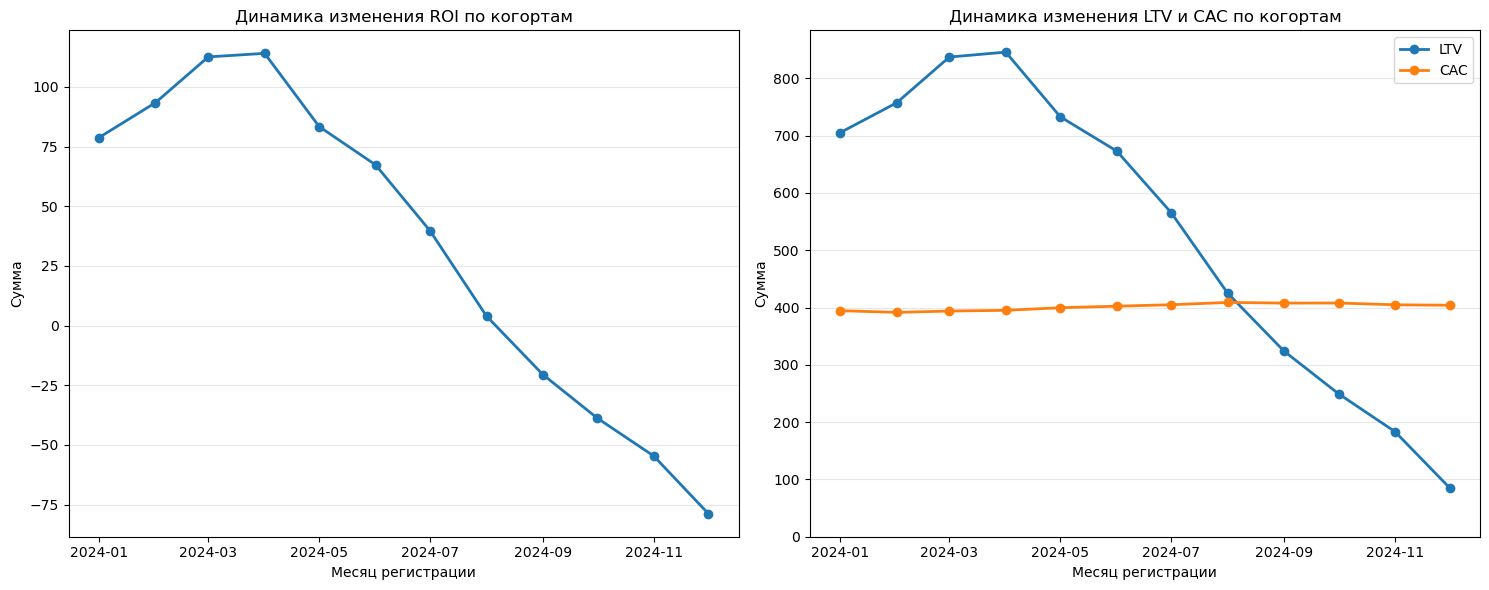

In [32]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(cohort_stat['cohort_month'], cohort_stat['roi'], label = 'ROI', marker='o', linewidth=2)
    
plt.title(f'Динамика изменения ROI по когортам')
plt.xlabel('Месяц регистрации')
plt.ylabel('Сумма')
plt.grid(axis='y', alpha=0.3)
plt.xticks()

plt.subplot(1,2,2)

plt.plot(cohort_stat['cohort_month'], cohort_stat['ltv'], label = 'LTV', marker='o', linewidth=2)
plt.plot(cohort_stat['cohort_month'], cohort_stat['cac'], label = 'CAC', marker='o', linewidth=2)
plt.legend()    
plt.title(f'Динамика изменения LTV и CAC по когортам')
plt.xlabel('Месяц регистрации')
plt.ylabel('Сумма')
plt.grid(axis='y', alpha=0.3)
plt.xticks()
plt.ylim(0)
plt.tight_layout()
plt.show()

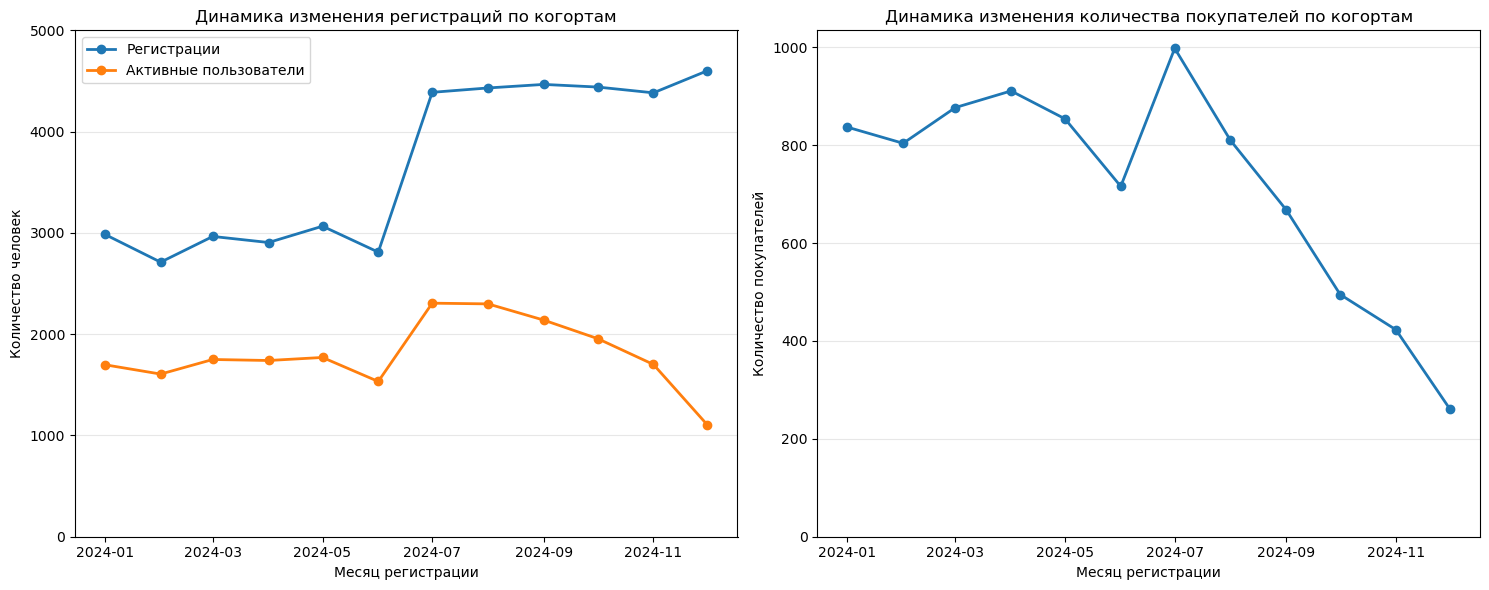

In [33]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(cohort_stat['cohort_month'], cohort_stat['cohort_users'], label = 'Регистрации', marker='o', linewidth=2)
plt.plot(cohort_stat['cohort_month'], cohort_stat['cohort_event_users'], label = 'Активные пользователи', marker='o', linewidth=2)

plt.legend()    
plt.title(f'Динамика изменения регистраций по когортам')
plt.xlabel('Месяц регистрации')
plt.ylabel('Количество человек')
plt.grid(axis='y', alpha=0.3)
plt.xticks()
plt.ylim(0,5000)
plt.subplot(1,2,2)

plt.plot(cohort_stat['cohort_month'], cohort_stat['cohort_payers'], label = 'ПОкупатели', marker='o', linewidth=2)
    
plt.title(f'Динамика изменения количества покупателей по когортам')
plt.xlabel('Месяц регистрации')
plt.ylabel('Количество покупателей')
plt.grid(axis='y', alpha=0.3)
plt.xticks()
plt.ylim(0)
plt.tight_layout()
plt.show()

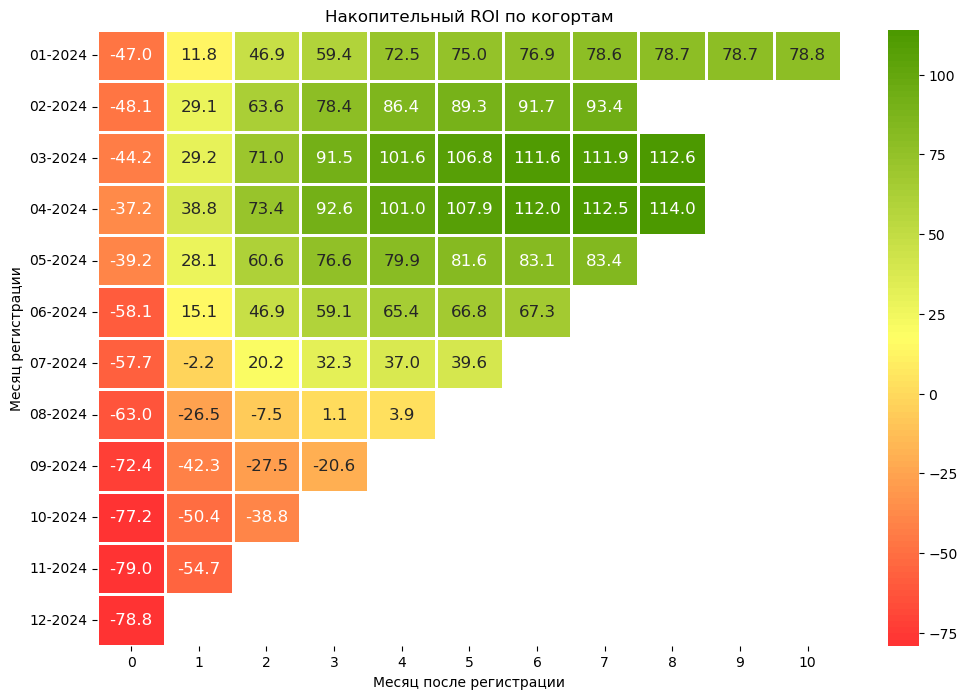

In [34]:
orders_full['revenue'] = orders_full['total_price']*0.05
users_ltv_cum = orders_full[['order_id', 'user_id', 'revenue', 'lifetime', 'period', 'cohort_month', 'acq_channel']]
users_ltv_cum = pd.merge(users_ltv_cum, cohort_stat[['cohort_month', 'cac','cohort_users']], how = 'left', on = 'cohort_month')

users_ltv_cum = users_ltv_cum.groupby(['cohort_month', 'period', 'cohort_users']).agg(
    revenue = ('revenue','sum'),
    cac = ('cac', 'mean')).reset_index()

users_ltv_cum = users_ltv_cum.sort_values(['cohort_month', 'period'])
users_ltv_cum['revenue_cum'] = users_ltv_cum.groupby(['cohort_month'])['revenue'].cumsum()
users_ltv_cum['ltv_cum'] = users_ltv_cum['revenue_cum']/users_ltv_cum['cohort_users']
users_ltv_cum['roi_cum'] = (users_ltv_cum['ltv_cum'] - users_ltv_cum['cac'])/users_ltv_cum['cac']*100

roi_cum = users_ltv_cum.pivot_table(
        index='cohort_month',
        columns='period',
        values='roi_cum',
    )

roi_cum[roi_cum == 0] = float('nan')
roi_cum.index = roi_cum.index.strftime('%m-%Y')  

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

plt.figure(figsize=(12, 8))
sns.heatmap(roi_cum,
           cmap=cmap,
           annot=True,
           fmt='.1f',
           linewidths=2,
           annot_kws={"size": 12})

plt.title('Накопительный ROI по когортам')
plt.xlabel('Месяц после регистрации')
plt.ylabel('Месяц регистрации')
plt.show()


Верхнеуровневые метрики бизнеса имеют сильный негативный тренд. С мая 2024 имеют сильное снижение ROI. Это снижение является результатом резкого уменьшения LTV покупателей. Одновременно наблюдается резкое увеличение количества привлекаемых пользователей во всех когортах, начиная с "07-2024". При этом, несмотря на то, что в целом наблюдается прирост аудитории ('cohort_users'), количество плательщиков ('cohort_payers') среди них имеет резкое снижение. Резкое изменение количества пользователей совпадает по времени с резким изменением маркетингового бюджета. Все это указывает, на то, что изменение маркетинговой стратегии привело к ухудшениям в  привлечении пользователей, маркетинговый бюджет тратится неэффективно и приводит нерелевантную аудиторию. В результате наблюдается сильное снижение LTV и падение окупаемости бизнеса.

## Выводы по результатам анализа бизнес-показателей


Основные точки роста:
- Низкий уроень **retention rate**: наблюдается высокий отток пользователей в течение всего года, уровень retention rate падает до 20-25% уже к третьему месяцу, повторные покупки через 5 месяцев после регистрации делают менее 10% пользователей.  Лояльность пользователей остается на низком уровне: среднее количество заказов составляет всего 3.5 на пользователя, при этом большинство ограничивается 1-3 заказами за все время. Активность аудитории демонстрирует негативную динамику: после достижения пика в августе (3861 пользователь) MAU снизилось до 3336 к декабрю.

- В годовой динамике наблюдается перелом для метрик монетизации и смена положительного тренда на негативный, свопадающий с изменением бюджета маркетинговой стратегии. **ROI** снижается с мая 2024 года, маркетинговые инвестиции не окупаются с августа 2024. Падение LTV пользователей привело к снижению окупаемости бизнеса. Увеличение маркетингового бюджета на 50% (с 1.2 до 1.8 млн рублей) в июле не привело к положительным трендам в монетизации. Одновременно с увеличением маркетингового бюджета, для всех когорт новых пользователей, зарегистрированных в июле или позже наблюдается снижение ROI. По-видимому, это связано с привлечением новой нерелевантной аудитории. Рекомендуется пересмотр маркетинговой стратегии с фокусом на качество трафика, а не его количество. 


## Анализ бизнес-метрик в разрезе каналов привлечения, анализ пользовательской воронки


Так как основная проблема с ROI лежит в области неэффективного расходования маркетингового бюджета, рассматриваем  метрики в разрезе по каналам привлечения.

In [40]:
monthly_cohorts_channels = pa_marketplace_users.groupby(['acq_channel','cohort_month'])['user_id'].nunique().reset_index()
monthly_cohorts_channels['cohort_month'] = pd.to_datetime(monthly_cohorts_channels['cohort_month'])
monthly_cohorts_channels = monthly_cohorts_channels.rename (columns = {'user_id': 'cohort_users'})
segmented_costs = pa_marketplace_campaign_costs.groupby(['acq_channel','spend_month'])['budget'].sum().reset_index()
segmented_costs['spend_month'] = pd.to_datetime(segmented_costs['spend_month'])
orders_full['revenue'] = orders_full['total_price']*0.05
cohort_stat_channels = orders_full.groupby(['acq_channel','cohort_month']).agg({
    'revenue': 'sum',
    'user_id': 'nunique'
}).reset_index()
cohort_stat_channels['cohort_month'] = pd.to_datetime(cohort_stat_channels['cohort_month'])
cohort_stat_channels = cohort_stat_channels.rename (columns = {'user_id': 'cohort_payers'})

cohort_stat_channels = pd.merge(cohort_stat_channels, monthly_cohorts_channels, how = 'left', on = ['acq_channel','cohort_month'])
cohort_stat_channels = pd.merge(cohort_stat_channels, segmented_costs, how = 'left',
                                left_on = ['acq_channel','cohort_month'], right_on = ['acq_channel','spend_month'])

cohort_stat_channels['ltv'] = cohort_stat_channels['revenue']/ cohort_stat_channels['cohort_users']

cohort_stat_channels['cac'] = cohort_stat_channels['budget']/cohort_stat_channels['cohort_users']
cohort_stat_channels['roi'] = (cohort_stat_channels['ltv'] - cohort_stat_channels['cac'])/cohort_stat_channels['cac']*100

In [41]:
ltv_roi_30_channels = orders_full_30.groupby(['acq_channel','cohort_month']).agg(revenue_30 = ('total_price','sum')).reset_index()
ltv_roi_30_channels['revenue_30'] = ltv_roi_30_channels['revenue_30']*0.05
cohort_stat_channels = cohort_stat_channels.merge(ltv_roi_30_channels, how = 'left', on = ['acq_channel','cohort_month'])
cohort_stat_channels['ltv_30'] = cohort_stat_channels['revenue_30']/cohort_stat_channels['cohort_users']
cohort_stat_channels['roi_30'] = (cohort_stat_channels['ltv_30'] - cohort_stat_channels['cac'])/cohort_stat_channels['cac']*100
display(cohort_stat_channels.head())

,acq_channel,cohort_month,revenue,cohort_payers,cohort_users,spend_month,budget,ltv,cac,roi,revenue_30,ltv_30,roi_30
0,Affiliate,2024-01-01,562577.7950,204,575,2024-01-01,179343.3875,978.396165,311.901543,213.687504,294701.4405,512.524244,64.322446
1,Affiliate,2024-02-01,678519.2015,231,559,2024-02-01,175488.4875,1213.808947,313.932894,286.645991,342647.2090,612.964596,95.253383
2,Affiliate,2024-03-01,759197.0910,223,530,2024-03-01,164543.4750,1432.447342,310.459387,361.396048,382151.6845,721.040914,132.249674
3,Affiliate,2024-04-01,713029.0025,246,596,2024-04-01,186869.9750,1196.357387,313.540227,281.564241,362798.8925,608.722974,94.145096
4,Affiliate,2024-05-01,862685.4970,238,532,2024-05-01,166443.7750,1621.589280,312.864239,418.304453,472919.2065,888.945877,184.131507


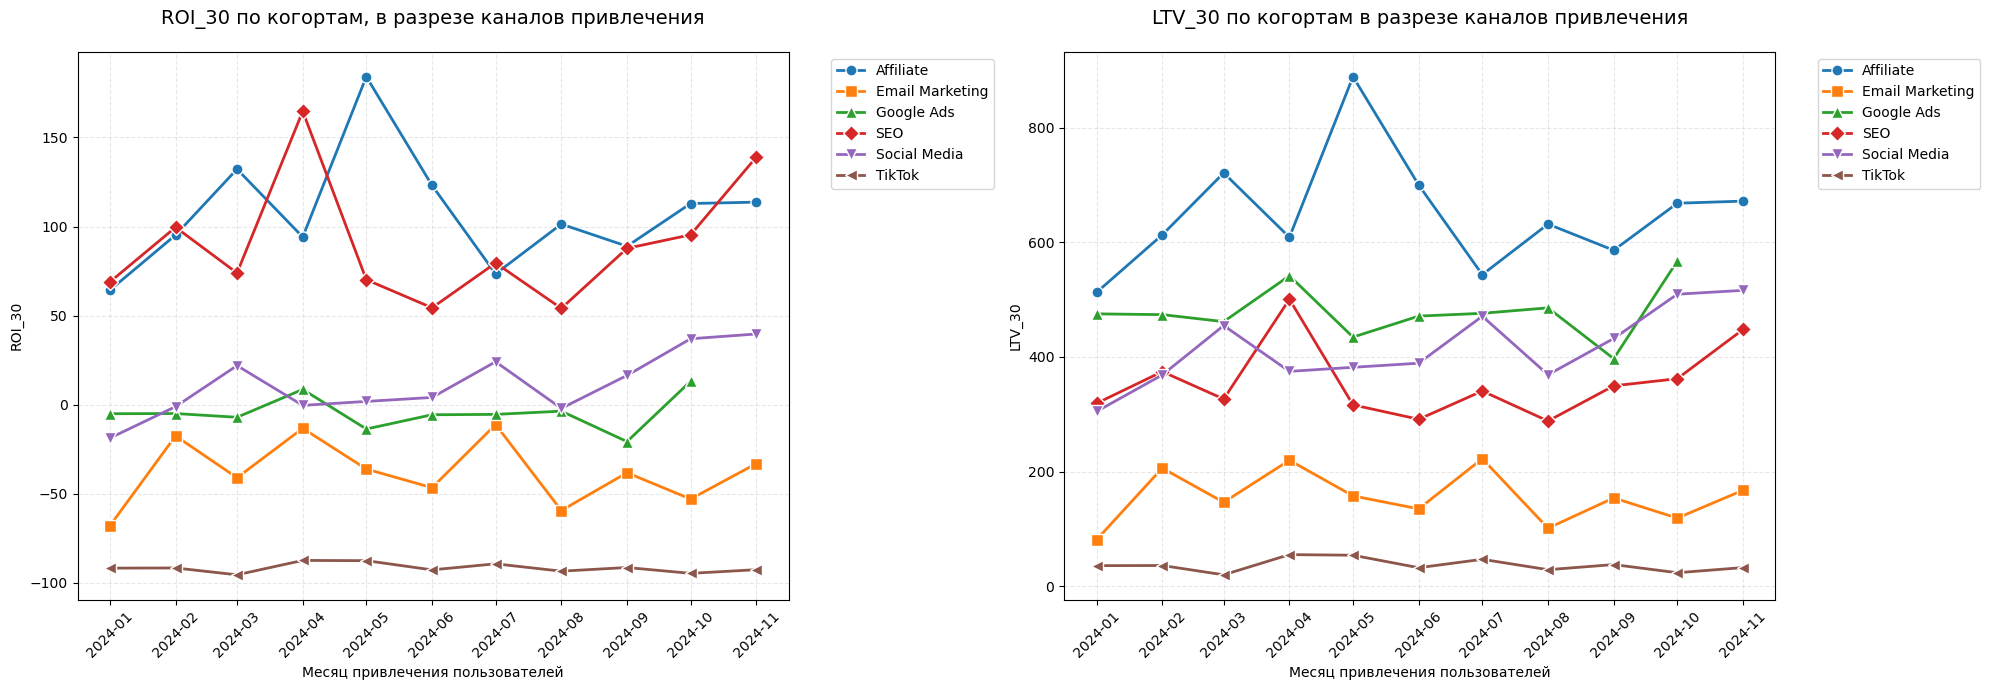

In [42]:
metric = 'roi_30'
plt.figure(figsize=(20, 7))

plt.subplot(1,2,1)
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, channel in enumerate(cohort_stat_channels['acq_channel'].unique()):
    plt_df = cohort_stat_channels[cohort_stat_channels['acq_channel'] == channel]
    
    plt.plot(plt_df['cohort_month'], plt_df[metric], 
             label=channel,
             marker=markers[i % len(markers)],  # Циклически используем маркеры
             markersize=8,
             linewidth=2,
             markeredgecolor='white',
             markeredgewidth=1)

# Добавляем сетку
plt.grid(True, alpha=0.3, linestyle='--')

plt.title(f"{metric.upper()} по когортам, в разрезе каналов привлечения", fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel(metric.upper())
plt.xticks(rotation=45)

metric = 'ltv_30'
plt.subplot(1,2,2)

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, channel in enumerate(cohort_stat_channels['acq_channel'].unique()):
    plt_df = cohort_stat_channels[cohort_stat_channels['acq_channel'] == channel]
    
    plt.plot(plt_df['cohort_month'], plt_df[metric], 
             label=channel,
             marker=markers[i % len(markers)],  # Циклически используем маркеры
             markersize=8,
             linewidth=2,
             markeredgecolor='white',
             markeredgewidth=1)

# Добавляем сетку
plt.grid(True, alpha=0.3, linestyle='--')

plt.title(f"{metric.upper()} по когортам в разрезе каналов привлечения", fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel(metric.upper())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Самый неэффективный рекламный канал, он же и самый затратный - 'TikTok'. Также не окупаются вложения в 'Email-marketing', в районе нулевой окупаемости канал 'Google Ads'. Остальные рекламные каналы имеют положительную окупаемость, наиболее высокий ROI наблюдается для каналов 'SEO' и 'Affiliate'. Данные каналы привлекают наиболее лояльную и платежеспособную аудиторию.

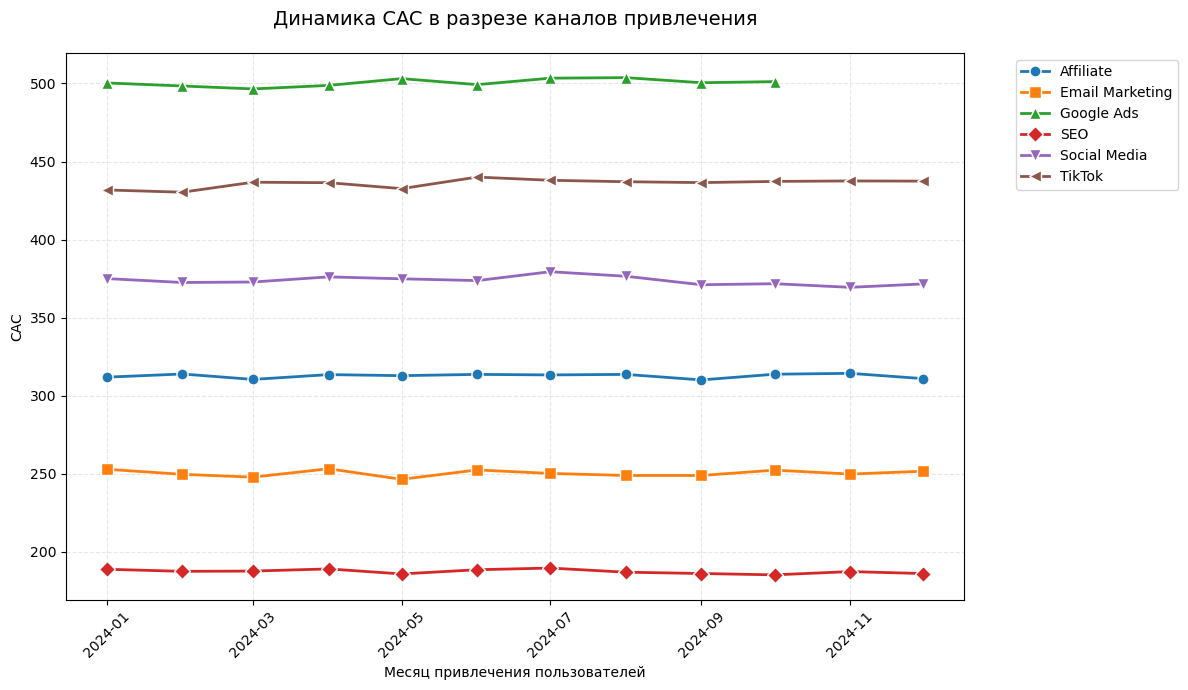

In [44]:
metric = 'cac'
plt.figure(figsize=(12, 7))

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, channel in enumerate(cohort_stat_channels['acq_channel'].unique()):
    plt_df = cohort_stat_channels[cohort_stat_channels['acq_channel'] == channel]
    
    plt.plot(plt_df['cohort_month'], plt_df[metric], 
             label=channel,
             marker=markers[i % len(markers)],  # Циклически используем маркеры
             markersize=8,
             linewidth=2,
             markeredgecolor='white',
             markeredgewidth=1)

plt.grid(True, alpha=0.3, linestyle='--')

plt.title(f"Динамика {metric.upper()} в разрезе каналов привлечения", fontsize=14, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Месяц привлечения пользователей')
plt.ylabel(metric.upper())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

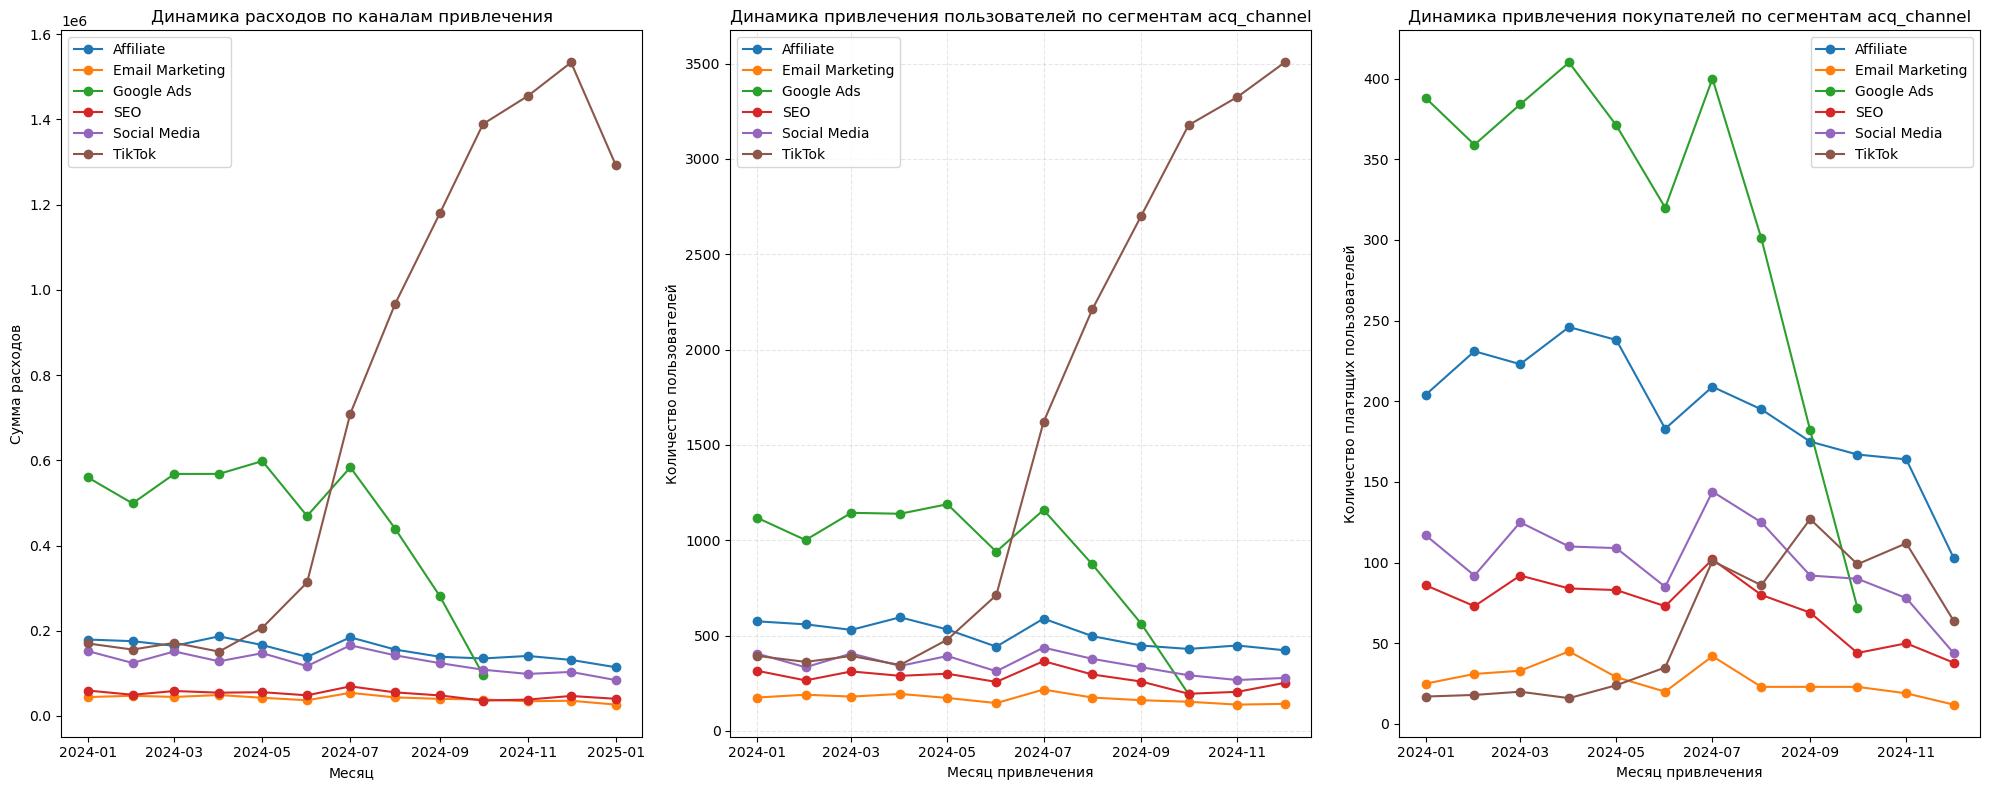

In [45]:
segments = 'acq_channel'
users_segmented = pa_marketplace_users.groupby([segments, 'cohort_month']).agg(
    users = ('user_id', 'nunique'),
    payers = ('payer_flag', 'sum')).reset_index()

plt.figure(figsize = (20,8))
plt.subplot(1,3,1)
for segment in users_segmented['acq_channel'].unique():
    plt_df = segmented_costs[segmented_costs['acq_channel'] == segment]
    plt.plot(plt_df['spend_month'],plt_df['budget'], label = segment, marker = 'o')
plt.title(f'Динамика расходов по каналам привлечения')
plt.legend()
plt.xlabel('Месяц')
plt.ylabel('Сумма расходов')

plt.subplot(1,3,2)
for segment in users_segmented[segments].unique():
    plt_df = users_segmented[users_segmented[segments] == segment]
    plt.plot(plt_df['cohort_month'],plt_df['users'], label = segment, marker = 'o')
plt.title(f'Динамика привлечения пользователей по сегментам {segments}')
plt.grid(True, alpha=0.3, linestyle='--')

plt.legend()
plt.xlabel('Месяц привлечения')
plt.ylabel('Количество пользователей')

plt.subplot(1,3,3)
for segment in users_segmented[segments].unique():
    plt_df = users_segmented[users_segmented[segments] == segment]
    plt.plot(plt_df['cohort_month'],plt_df['payers'], label = segment, marker = 'o')
plt.title(f'Динамика привлечения покупателей по сегментам {segments}')
plt.legend()
plt.xlabel('Месяц привлечения')
plt.ylabel('Количество платящих пользователей')
plt.tight_layout()
plt.show()

В июле 2024 года, по-видимому, была сильно изменена маркетинговая стратегия: отключен рекламный канал 'GoogleAds', который приводил самое большое количество платящих пользователей, а средства перераспределены в развитие рекламного канала 'TikTok'.  Начиная с июня маркетинговый бюджет на 'TikTok' был сильно увеличен, это привело к увеличению аудитории маркетплейса, однако количество платящих пользователей, которые пришли из канала 'TikTok'  имеет совсем небольшое увеличение. Привлечение нерелевантной аудитории  за большой бюджет отразилось в резком увеличении CAC. Рекомендуется пересмотреть маркетинговую стратегию, приостановить бюджетирование рекламного канала 'TikTok' или пересмотреть рекламную стратегию в TikTok.

In [47]:
funnel_steps = ['page_view', 'product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete']
df_funnel = pa_marketplace_events[pa_marketplace_events['event_type'].isin(funnel_steps)]
df_funnel = df_funnel.groupby('event_type')['event_id'].nunique().reindex(funnel_steps).reset_index()
orders_count = pd.DataFrame({
    'event_type': ['order'],
    'event_id': [pa_marketplace_orders['order_id'].nunique()]
})
df_funnel = pd.concat([df_funnel, orders_count], ignore_index=True)

df_funnel['CR'] = (df_funnel['event_id']/df_funnel['event_id'].iloc[0]*100).round(1)
df_funnel['CR_prev_step'] = (df_funnel['event_id']/df_funnel['event_id'].shift(1)*100).round(1)

print(df_funnel)

          event_type  event_id     CR  CR_prev_step
0          page_view    120159  100.0           NaN
1       product_view    119831   99.7          99.7
2      product_click    116574   97.0          97.3
3        add_to_cart    105716   88.0          90.7
4     checkout_start     88133   73.3          83.4
5  checkout_complete     80103   66.7          90.9
6              order     30446   25.3          38.0


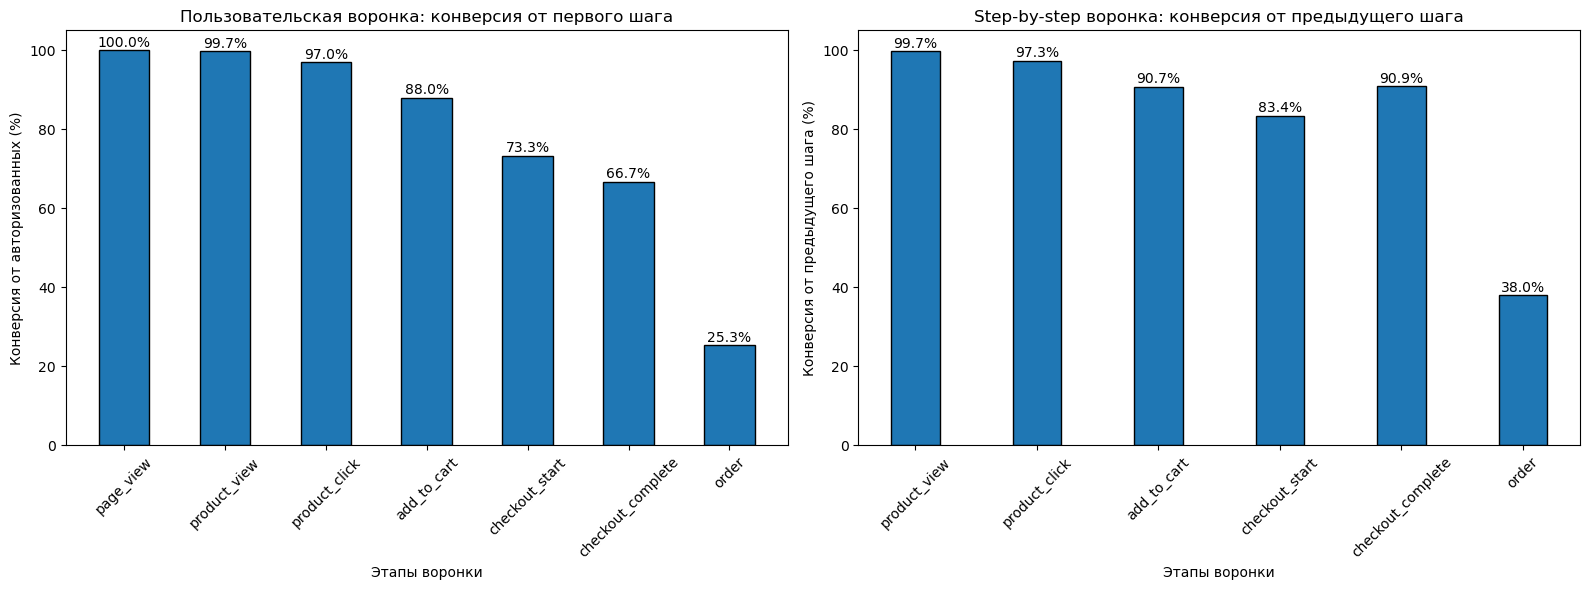

In [48]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
bars = plt.bar(df_funnel['event_type'], df_funnel['CR'], width=0.5, edgecolor='k')
plt.title('Пользовательская воронка: конверсия от первого шага')
plt.ylabel('Конверсия от авторизованных (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%',  # Форматируем значение с одним знаком после запятой
             ha='center', va='bottom', fontsize=10)

plt.subplot(1, 2, 2)
plt_df = df_funnel.iloc[1:]
bars = plt.bar(plt_df['event_type'], plt_df['CR_prev_step'], width = 0.4, edgecolor = 'k')
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.ylim(0,105)
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%',  # Форматируем значение с одним знаком после запятой
             ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()

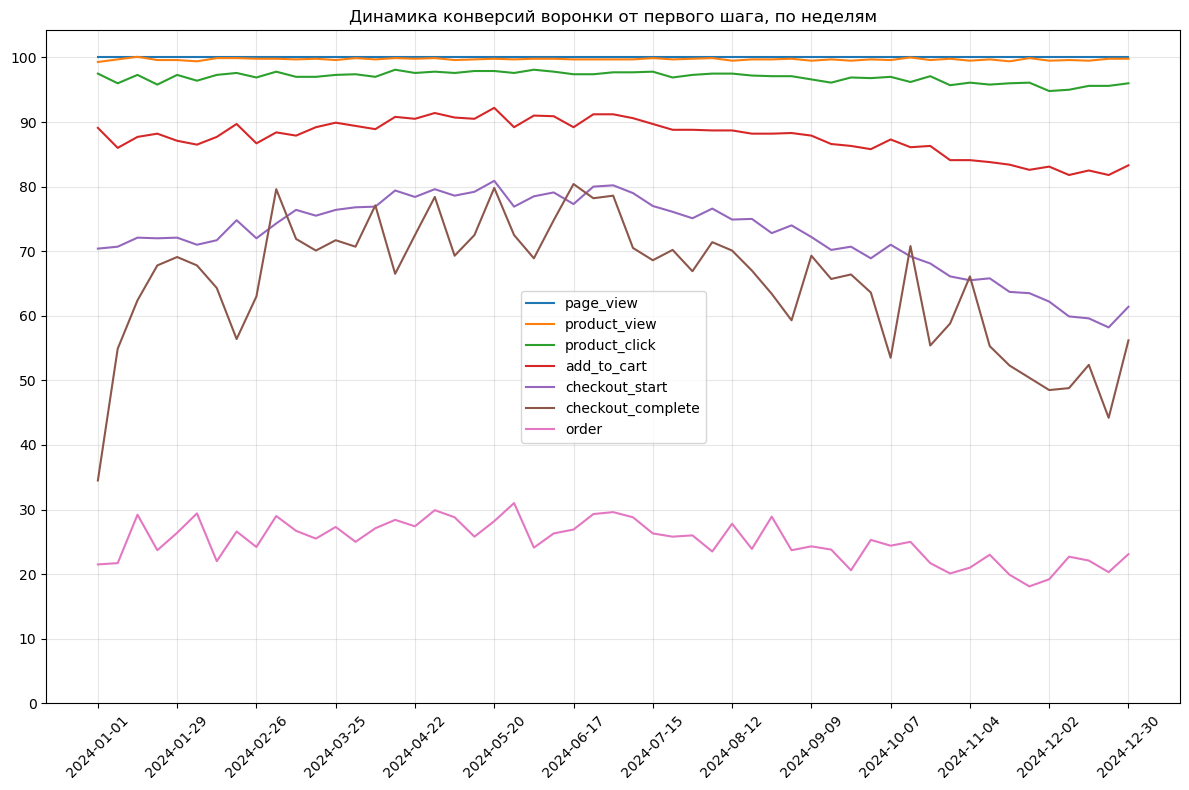

In [49]:
events_weekly = pa_marketplace_events[pa_marketplace_events['event_type'].isin(funnel_steps)]
events_weekly = events_weekly.groupby(['event_type', 'event_week'])['event_id'].nunique().reset_index()
events_weekly = events_weekly.rename(columns={'event_id': 'count'})

orders_weekly = pa_marketplace_orders.groupby('order_week')['order_id'].nunique().reset_index()
orders_weekly = orders_weekly.rename(columns={'order_week': 'event_week', 'order_id': 'count'})
orders_weekly['event_type'] = 'order'

df_funnel_weekly = pd.concat([events_weekly, orders_weekly], ignore_index=True)

funnel_steps_complete = funnel_steps + ['order']
df_funnel_weekly['event_type'] = pd.Categorical(
    df_funnel_weekly['event_type'], 
    categories=funnel_steps_complete, 
    ordered=True
)
conversion_data =[]
df_funnel_weekly = df_funnel_weekly.sort_values(['event_week', 'event_type'])
for week in df_funnel_weekly['event_week'].unique():
    week_data = df_funnel_weekly[df_funnel_weekly['event_week'] == week].copy()
    
    if len(week_data) == len(funnel_steps_complete):
        week_data['CR'] = (week_data['count'] / week_data['count'].iloc[0] * 100).round(1)
        week_data['CR_prev_step'] = (week_data['count'] / week_data['count'].shift(1) * 100).round(1)
        week_data.loc[week_data.index[0], 'CR_prev_step'] = 100.0
        
        conversion_data.append(week_data)

df_funnel_weekly_cr = pd.concat(conversion_data, ignore_index=True)


plt.figure(figsize=(12, 8))

for step in funnel_steps_complete:
    df_step = df_funnel_weekly_cr[df_funnel_weekly_cr['event_type'] == step]
    plt.plot(df_step['event_week'], df_step['CR'], label=step)

plt.title('Динамика конверсий воронки от первого шага, по неделям')

plt.yticks(np.arange(0, 101, 10))  

plt.xticks(rotation=45)  #

ax = plt.gca()
ax.xaxis.set_major_locator(plt.MaxNLocator(16))  

plt.legend()
plt.grid(True, alpha=0.3)  # добавление сетки для лучшей читаемости
plt.tight_layout()  # автоматическая подгонка layout
plt.show()

In [50]:
checkouts = pa_marketplace_events[(pa_marketplace_events['event_type'] == 'checkout_complete')][['user_id','event_id', 'event_date','event_type', 'os','device']]
checkouts = checkouts.merge(pa_marketplace_users[['user_id', 'acq_channel']], how = 'left', on = 'user_id')
users_o_events = pa_marketplace_orders[['user_id', 'order_id','order_date']].copy()
users_o_events['event_type'] = 'order'
users_o_events = users_o_events.rename(columns = {'order_id':'event_id'})
users_o_events['event_date'] =  pd.to_datetime(users_o_events['order_date']).dt.date
checkouts_info = checkouts[['user_id', 'event_date', 'os','device', 'acq_channel']].drop_duplicates()
users_o_events['event_date'] = pd.to_datetime(users_o_events['event_date'])
checkouts_info['event_date'] = pd.to_datetime(checkouts_info['event_date'])
users_o_events = users_o_events.merge(checkouts_info, how = 'left', on = ['user_id', 'event_date'])

In [51]:
funnel_events = pa_marketplace_events[pa_marketplace_events['event_type'].isin(funnel_steps)][['user_id', 'event_id','event_type', 'os', 'device']]
funnel_events = pd.concat([funnel_events, users_o_events[['user_id', 'event_id', 'event_type', 'os', 'device']]])
funnel_events = funnel_events.merge(pa_marketplace_users[['user_id','age','gender', 'region','buyer_segment','acq_channel']], how = 'left', on = 'user_id')
funnel_events['age_group'] = pd.cut(funnel_events['age'],bins=[0, 25, 35, 45, 100],
                                   labels=['18-25', '26-35', '36-45', '45+'])

In [52]:
funnel_by_channel = (funnel_events
    .groupby(['acq_channel', 'event_type'])['event_id']
    .nunique()
    .reset_index()
    .rename(columns={'event_id': 'event_count'}))

funnel_pivot = funnel_by_channel.pivot(
    index='acq_channel', 
    columns='event_type', 
    values='event_count'
).fillna(0)

funnel_pivot = funnel_pivot[funnel_steps_complete]

print("Абсолютные значения событий по каналам привлечения:")
display(funnel_pivot)

Абсолютные значения событий по каналам привлечения:


event_type,page_view,product_view,product_click,add_to_cart,checkout_start,checkout_complete,order
acq_channel,,,,,,,
Affiliate,26775,26721,26266,24727,22228,21156,9668
Email Marketing,10656,10608,10254,9011,7050,6068,793
Google Ads,37501,37423,36630,34038,29747,27845,11896
SEO,19404,19357,18913,17306,14725,13665,2803
Social Media,10371,10348,10057,9195,7724,6988,3978
TikTok,15452,15374,14454,11439,6659,4381,1308


In [53]:
funnel_conversion = funnel_pivot.copy()
funnel_conversion = (funnel_conversion.divide(funnel_conversion.iloc[:, 0], axis=0) * 100).round(2)
display(funnel_conversion)

event_type,page_view,product_view,product_click,add_to_cart,checkout_start,checkout_complete,order
acq_channel,,,,,,,
Affiliate,100.0,99.80,98.10,92.35,83.02,79.01,36.11
Email Marketing,100.0,99.55,96.23,84.56,66.16,56.94,7.44
Google Ads,100.0,99.79,97.68,90.77,79.32,74.25,31.72
SEO,100.0,99.76,97.47,89.19,75.89,70.42,14.45
Social Media,100.0,99.78,96.97,88.66,74.48,67.38,38.36
TikTok,100.0,99.50,93.54,74.03,43.09,28.35,8.46


In [54]:
funnel_sbs = pd.DataFrame()

for i in range(1, len(funnel_pivot.columns)):
    current_col = funnel_pivot.columns[i]
    prev_col = funnel_pivot.columns[i-1]
    
    funnel_sbs[current_col] = (
        funnel_pivot[current_col] / funnel_pivot[prev_col] * 100
    ).round(2)

print("Step-by-step конверсия (%):")
display(funnel_sbs)

Step-by-step конверсия (%):


,product_view,product_click,add_to_cart,checkout_start,checkout_complete,order
acq_channel,,,,,,
Affiliate,99.80,98.30,94.14,89.89,95.18,45.70
Email Marketing,99.55,96.66,87.88,78.24,86.07,13.07
Google Ads,99.79,97.88,92.92,87.39,93.61,42.72
SEO,99.76,97.71,91.50,85.09,92.80,20.51
Social Media,99.78,97.19,91.43,84.00,90.47,56.93
TikTok,99.50,94.02,79.14,58.21,65.79,29.86


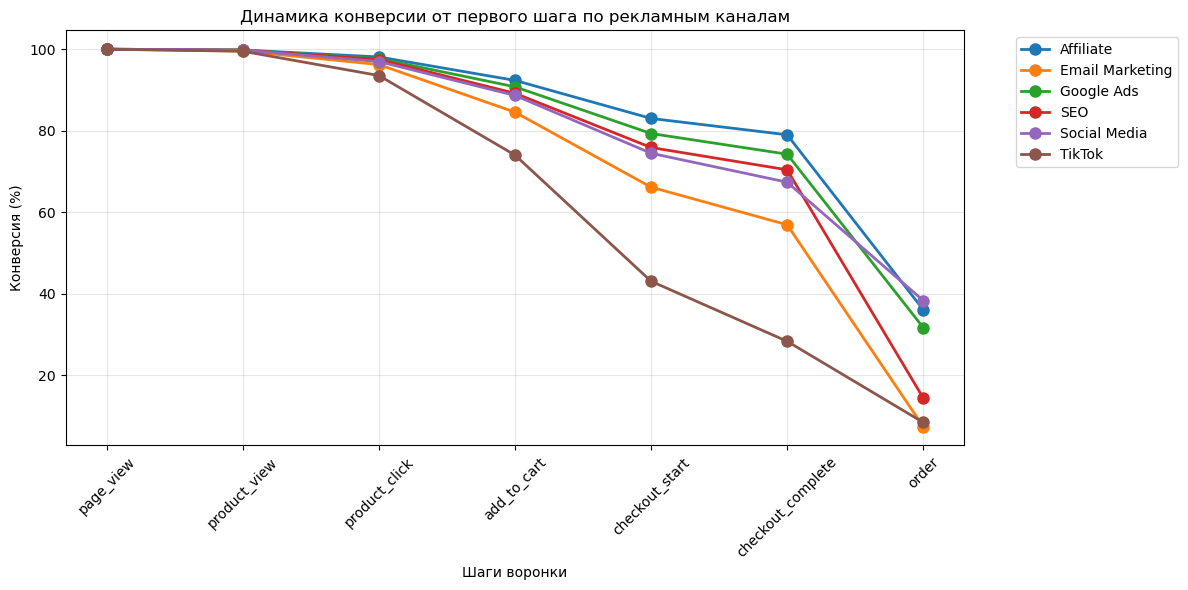

In [55]:
plt.figure(figsize=(12, 6))

for channel in funnel_conversion.index:
    plt.plot(funnel_conversion.columns, funnel_conversion.loc[channel], 
             marker='o', linewidth=2, label=channel, markersize=8)

plt.xlabel('Шаги воронки')
plt.ylabel('Конверсия (%)')
plt.title('Динамика конверсии от первого шага по рекламным каналам')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  Рассмотрела пользовательскую воронку по каналам привлечения. 
Конверсия пользователей, привлеченных из 'TikTok' почти на всех шагах пользовательской воронки ниже, чем конверсии пользователей  привлеченных по по остальным рекламным каналам. Менее 50% сессий пользователей из 'TikTok' доходят до начала оформления заказа. Пользователи прривлеченные по каналу 'E-mail marketing' также имеют низкие, по сранвению с остальными пользователями, конверсии на шагах добавления товара в корзину и оформления заказов.


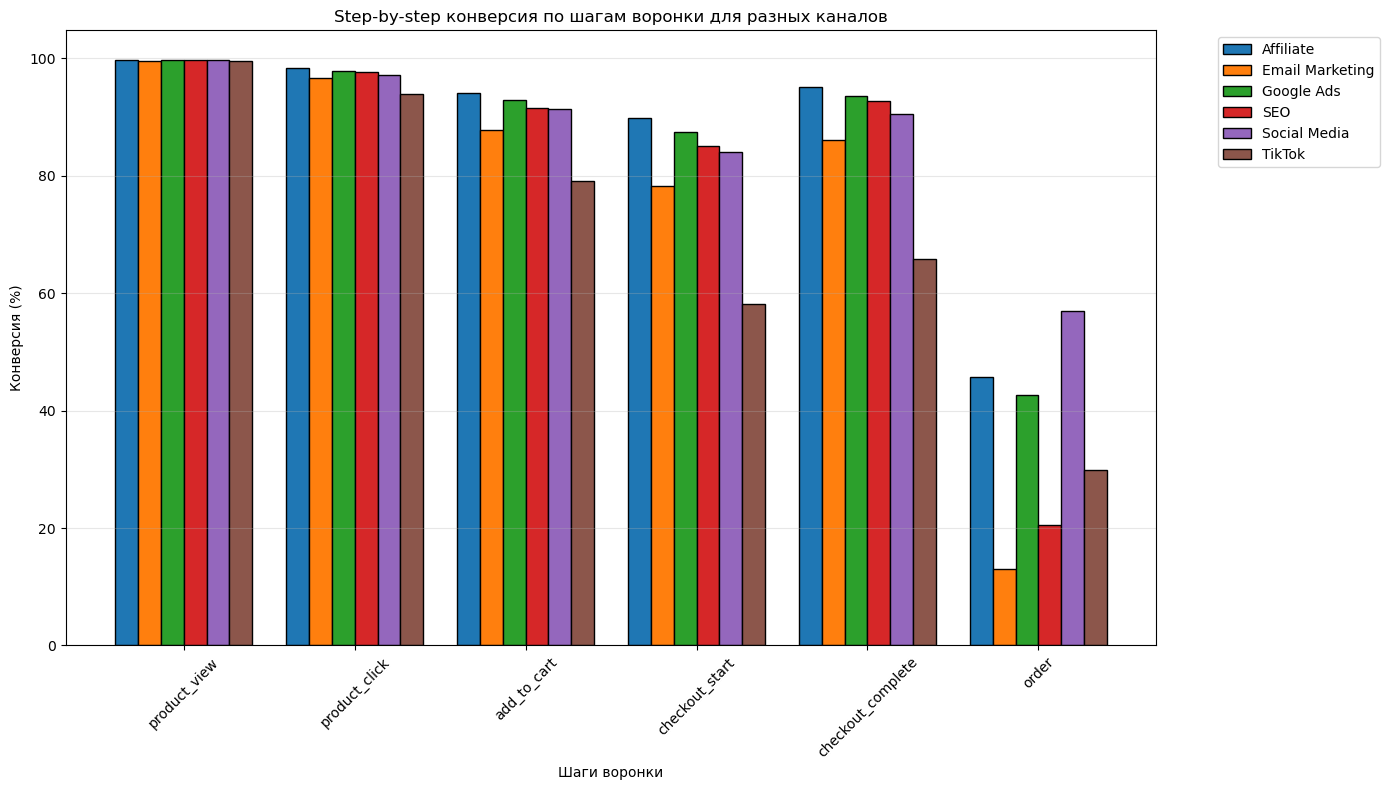

In [57]:
plt.figure(figsize=(14, 8))

channels = funnel_sbs.index
steps = funnel_sbs.columns
x = np.arange(len(steps))
width = 0.8 / len(channels)

for i, channel in enumerate(channels):
    plt.bar(x + i*width, funnel_sbs.loc[channel], 
            width, label=channel, edgecolor = 'k')

plt.xlabel('Шаги воронки')
plt.ylabel('Конверсия (%)')
plt.title('Step-by-step конверсия по шагам воронки для разных каналов')
plt.xticks(x + width*(len(channels)-1)/2, steps, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Пользовательская воронка с анализом step-by-step конверсий по каналам привлечения, показывает, что  пользователи из TikTok  хуже всего проходят шаги пользовательской воронки от добавления товара в корзину до оплаченного заказа. 
Пользователи прривлеченные по каналу 'E-mail marketing' также имеют низкие, по сранвению с остальными пользователями, конверсии на шагах добавления товара в корзину и оформления заказов. Также наблюдается резкое снижение конверсии на шаге оплаты заказа 'checkout_complete' -> 'order' у пользователей из каналов 'E-mail marketing' и 'SEO'. Данным пользователям можно добавить дополнительные напоминания об оплате заказа или другое стимулирующее оплату предложение.

TikTok. Конверсии от первого шага по age_group:


C:\Users\Деси\AppData\Local\Temp\ipykernel_24288\3357358554.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([segments, 'event_type'])['event_id']


event_type,page_view,product_view,product_click,add_to_cart,checkout_start,checkout_complete,order
age_group,,,,,,,
18-25,100.0,99.45,92.75,73.75,41.48,25.80,8.02
26-35,100.0,99.65,94.33,74.07,42.08,26.18,9.07
36-45,100.0,99.43,93.52,73.64,42.63,29.06,8.50
45+,100.0,99.48,93.48,74.25,44.14,29.64,8.35


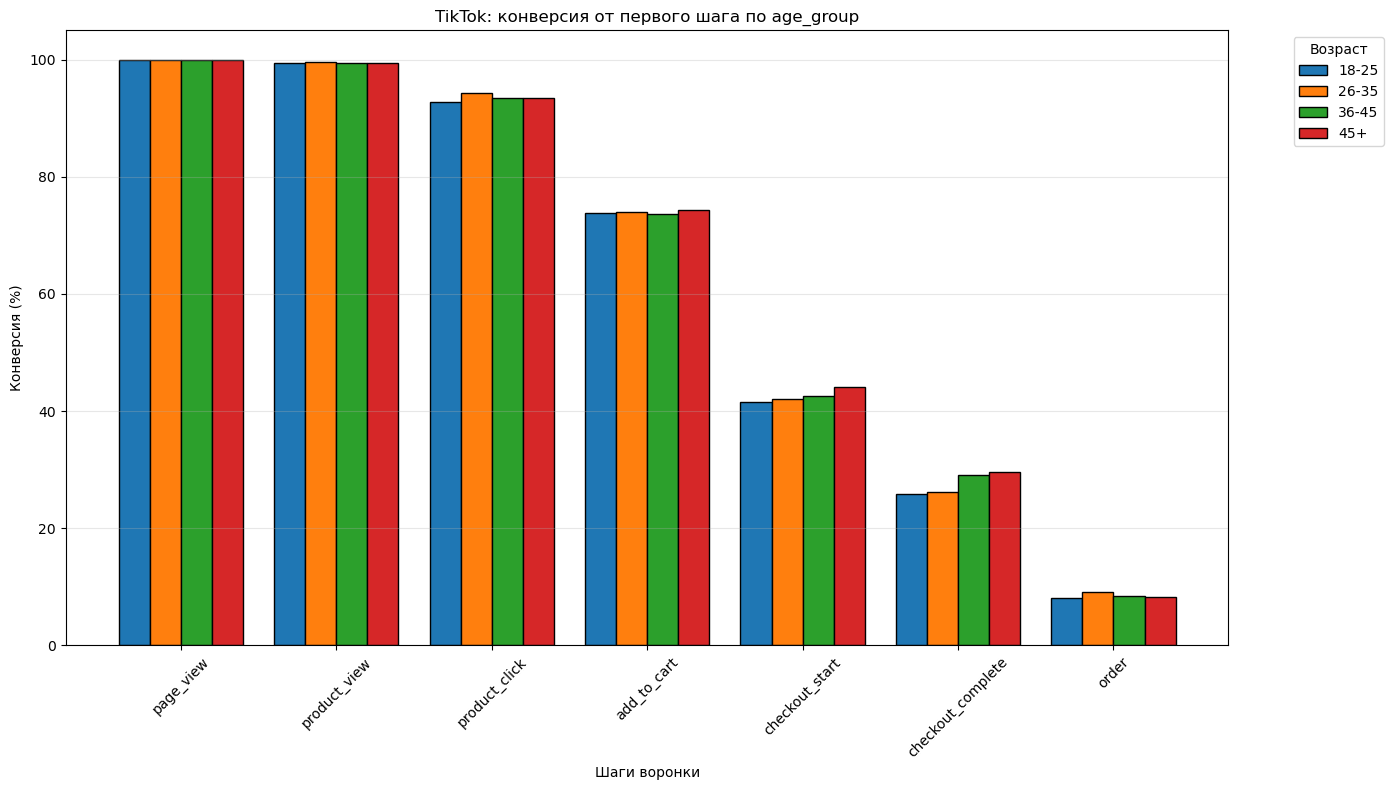

In [59]:
segments = 'age_group'
funnel_tiktok = (funnel_events[funnel_events['acq_channel'] == 'TikTok']
    .groupby([segments, 'event_type'])['event_id']
    .nunique()
    .reset_index()
    .rename(columns={'event_id': 'event_count'}))

funnel_tiktok_pivot = funnel_tiktok.pivot(
    index = segments, 
    columns='event_type', 
    values='event_count'
).fillna(0)

funnel_tiktok_pivot = funnel_tiktok_pivot[funnel_steps_complete]
funnel_tiktok_pivot = (funnel_tiktok_pivot.divide(funnel_tiktok_pivot.iloc[:, 0], axis=0) * 100).round(2)
print(f"TikTok. Конверсии от первого шага по {segments}:")
display(funnel_tiktok_pivot)

plt.figure(figsize=(14, 8))

channels = funnel_tiktok_pivot.index
steps = funnel_tiktok_pivot.columns
x = np.arange(len(steps))
width = 0.8 / len(channels)

for i, channel in enumerate(channels):
    plt.bar(x + i*width, funnel_tiktok_pivot.loc[channel], 
            width, label=channel, edgecolor = 'k')

plt.xlabel('Шаги воронки')
plt.ylabel('Конверсия (%)')
plt.title(f'TikTok: конверсия от первого шага по {segments}')
plt.xticks(x + width*(len(channels)-1)/2, steps, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title = 'Возраст')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Step-by-step конверсии всех шагов пользовательской воронки  кроме оплаты, по всем пользователям, имеют высокий уровень (более 80%), однако сегментирование пользователей по каналам привлечения выявляет неравномерность прохождения пользовательского пути юзерами, пришедшими из разных каналов.
- Конверсия в пользовательской воронке от первого шага 'page_view' до завершения оформления заказа составляет 66.7%,  конверсия в следующий шаг - успешный заказ составляет 25% от всех событий 'page_view' пользователей. Сильное снижение конверсий на шаге оплаты заказов наблюдается для пользователей из рекламных каналов 'E-mmail Marketing', 'SEO' и 'TikTok'. На этом шаге конверсия от предыдущего шага составялет менее 30%. 
- Сегментирование пользователей из рекламного канала 'TikTok' показывает, что конверсии шагов пользовательского пути не зависят от устройста или его операционной системы. Небольшое снижение конверсии из checkout_complete в orders наблюдается у пользователей Android. Также, молодые пользователи (до 35 лет) реже переходят от шага 'checkout_start' к 'checkout_complete'.

## Выводы по эффективности рекламных каналов и по шагам пользовательской воронки

В области маркетинга и привлечения пользователей выявлена значительная диспропорция в эффективности рекламных каналов. Канал 'TikTok' демонстрирует худшие показатели, являясь одновременно самым затратным и неокупаемым. Аналогичные проблемы наблюдаются с 'Email-marketing', который также не приносит положительной отдачи на инвестиции. В противоположность этому, каналы 'SEO' и 'Affiliate' показывают максимальную эффективность и ROI, привлекая наиболее лояльную и платежеспособную аудиторию. Остальные рекламные каналы демонстрируют положительную окупаемость.

Анализ пользовательской воронки выявил, что при высоких показателях конверсии на всех этапах (более 80%), общая конверсия от первого просмотра страницы до завершенного заказа составляет 25%. Наблюдается высокий отток пользователей на финальном этапе между оформлением заказа (checkout_complete) и его успешным завершением (order), где теряется более половины всех потенциальных покупателей, привлеченных через каналы 'E-mail Marketing', 'SEO' и 'TikTok'. 

Сегментный анализ показывает, что тип устройства и операционная система практически не влияют на конверсию в воронке, за исключением незначительного снижения показателей у пользователей Android на этапе checkout_complete → order. Это указывает на универсальный характер проблем в пользовательском опыте, не связанный с техническими особенностями устройств.

Рекомендуется провести перераспределение маркетингового бюджета и рекламной стратегии в неэффективных каналах привлечения,  сократив или полностью прекратив инвестиции в 'TikTok' и 'Email-marketing'. Для снижения высокого оттока на финальном этапе воронки можно внедрить систему стимулирующих напоминаний об оплате заказа, особенно для пользователей Android, а также провести углубленное исследование причин прерывания процесса покупки на последнем шаге.

## Подготовка A/B-эксперимента и подведение его результатов

### Дизайн эксперимента: бонус на первую покупку для пользователей TikTok
- **Бизнес-контекст:** Эксперимент направлен на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

### Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)

### Ключевые метрики
- **Основная метрика:** *Конверсия в первую покупку* — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку  
 *Цель:* увеличить конверсию с помощью бонуса  
 *Критерий успеха:* статистически значимый рост конверсии в тестовой группе  
  
- **Вспомогательные метрики:**
    - *ARPU* (средняя выручка на пользователя TikTok)
    - *ARPPU* (средняя выручка на покупателя TikTok)
    - *AOV* (средний чек TikTok)

- **Барьерная метрика:** *Общая выручка от пользователей TikTok*

### Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи (требования заказчика)

### Загрузка и предобработка данных по эксперименту

In [65]:
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv')
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv')
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv')
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')

In [66]:
events_AB = pd.merge(pa_marketplace_events_AB, pa_marketplace_AB_split_users, how = 'inner', on = 'user_id')
orders_AB = pd.merge(pa_marketplace_orders_AB, pa_marketplace_AB_split_users, how = 'inner', on = 'user_id')
users_AB = pd.merge(pa_marketplace_users_AB, pa_marketplace_AB_split_users, how = 'right', on = 'user_id')

In [67]:
print( 'Дублирующихся строк:', 
      events_AB.duplicated().sum(), 
      orders_AB.duplicated().sum(), 
      users_AB.duplicated().sum(), 
      pa_marketplace_AB_split_users.duplicated().sum())

orders_AB = orders_AB.drop_duplicates()
users_AB = users_AB.drop_duplicates()
events_AB = events_AB.drop_duplicates()

dfs = [orders_AB, users_AB, events_AB, pa_marketplace_AB_split_users]

for idx, df_clean in enumerate(dfs):
    print(f"\n--- DataFrame {idx + 1} ---")
    
    for column in df_clean.columns:
        if df_clean[column].dtype == 'object':
            unique_values = df_clean[column].unique()
            print(f'Уникальные значения в столбце "{column}": {len(unique_values)} значений')
            if len(unique_values) <= 10:
                print(f'  {unique_values}')
    
    print(df_clean.info())
    display(df_clean.head())


Дублирующихся строк: 0 0 0 0

--- DataFrame 1 ---
Уникальные значения в столбце "order_date": 136 значений
Уникальные значения в столбце "product_name": 141 значений
Уникальные значения в столбце "category_name": 25 значений
Уникальные значения в столбце "order_week": 4 значений
  ['2024-12-30' '2025-01-06' '2025-01-13' '2025-01-20']
Уникальные значения в столбце "order_month": 1 значений
  ['2025-01-01']
Уникальные значения в столбце "group": 2 значений
  ['treatment' 'control']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       255 non-null    int64  
 1   user_id        255 non-null    int64  
 2   order_date     255 non-null    object 
 3   product_name   255 non-null    object 
 4   quantity       255 non-null    int64  
 5   unit_price     255 non-null    float64
 6   total_price    255 non-null    float64
 7   category_

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment



--- DataFrame 2 ---
Уникальные значения в столбце "registration_date": 2852 значений
Уникальные значения в столбце "gender": 2 значений
  ['M' 'F']
Уникальные значения в столбце "region": 9 значений
  ['Новосибирск' 'Московская область' 'Нижний Новгород' 'Краснодар'
 'Санкт-Петербург' 'Москва' 'Ростов-на-Дону' 'Другие регионы'
 'Екатеринбург']
Уникальные значения в столбце "acq_channel": 1 значений
  ['TikTok']
Уникальные значения в столбце "buyer_segment": 4 значений
  ['one_time' 'rare' 'regular' 'medium']
Уникальные значения в столбце "cohort_week": 4 значений
  ['2024-12-30' '2025-01-06' '2025-01-13' '2025-01-20']
Уникальные значения в столбце "cohort_month": 1 значений
  ['2025-01-01']
Уникальные значения в столбце "group": 2 значений
  ['control' 'treatment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id          

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group
0,44965,2025-01-01 18:10:00,66,M,Новосибирск,TikTok,one_time,2024-12-30,2025-01-01,control
1,44967,2025-01-01 11:29:00,70,M,Московская область,TikTok,rare,2024-12-30,2025-01-01,control
2,44968,2025-01-01 13:05:00,68,F,Нижний Новгород,TikTok,regular,2024-12-30,2025-01-01,control
3,44969,2025-01-01 00:23:00,24,F,Краснодар,TikTok,medium,2024-12-30,2025-01-01,treatment
4,44970,2025-01-01 06:33:00,50,M,Санкт-Петербург,TikTok,regular,2024-12-30,2025-01-01,control



--- DataFrame 3 ---
Уникальные значения в столбце "event_date": 4345 значений
Уникальные значения в столбце "event_type": 15 значений
Уникальные значения в столбце "os": 4 значений
  ['Android' 'macOS' 'iOS' 'Windows']
Уникальные значения в столбце "device": 3 значений
  ['tablet' 'mobile' 'desktop']
Уникальные значения в столбце "product_name": 201 значений
Уникальные значения в столбце "event_week": 4 значений
  ['2024-12-30' '2025-01-06' '2025-01-13' '2025-01-20']
Уникальные значения в столбце "event_month": 1 значений
  ['2025-01-01']
Уникальные значения в столбце "group": 2 значений
  ['control' 'treatment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   event_id      4349 non-null   int64 
 1   user_id       4349 non-null   int64 
 2   event_date    4349 non-null   object
 3   event_type    4349 non-null   object
 4   os            

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month,group
0,844987,45076,2025-01-02 03:25:32,page_view,Android,tablet,NaN,2024-12-30,2025-01-01,control
1,844988,45076,2025-01-02 03:25:49,product_view,Android,tablet,Картина маслом,2024-12-30,2025-01-01,control
2,844989,45076,2025-01-02 03:26:23,product_click,Android,tablet,Сумка кожаная,2024-12-30,2025-01-01,control
3,844990,45076,2025-01-02 03:26:50,add_to_cart,Android,tablet,Дезодорант,2024-12-30,2025-01-01,control
4,844991,45076,2025-01-02 03:27:11,checkout_start,Android,tablet,NaN,2024-12-30,2025-01-01,control



--- DataFrame 4 ---
Уникальные значения в столбце "group": 2 значений
  ['control' 'treatment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB
None


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


In [68]:
print(f"Количество уникальных пользователей: {users_AB['user_id'].nunique()}")
print('Количество пользователей, попавших в две разные выборки:', len(set(users_AB[users_AB['group'] == 'control']['user_id'])& 
            set(users_AB[users_AB['group'] == 'treatment']['user_id'])))
print(f"Среднее количество OS на пользователя: {events_AB.groupby('user_id')['os'].nunique().mean()}")
print(f"Среднее количество device на пользователя: {events_AB.groupby('user_id')['device'].nunique().mean()}")
print(f"Первая регистрация: {users_AB['registration_date'].min()}") 
print(f"Последняя регистрация: {users_AB['registration_date'].max()}") 
print(f"Первый event: {events_AB['event_date'].min()}") 
print(f"Последний event: {events_AB['event_date'].max()}") 
print(f"Первый заказ: {orders_AB['order_date'].min()}") 
print(f"Последний заказ: {orders_AB['order_date'].max()}") 

Количество уникальных пользователей: 2968
Количество пользователей, попавших в две разные выборки: 0
Среднее количество OS на пользователя: 1.0
Среднее количество device на пользователя: 1.0
Первая регистрация: 2025-01-01 00:05:00
Последняя регистрация: 2025-01-26 23:41:00
Первый event: 2025-01-02 03:25:32
Последний event: 2025-01-26 23:46:15
Первый заказ: 2025-01-01 11:57:43
Последний заказ: 2025-01-26 20:39:35


In [69]:
print('Количество пользователей, попавших в orders и events:', len(set(orders_AB['user_id'])& 
            set(events_AB['user_id'])))

Количество пользователей, попавших в orders и events: 49


In [70]:
orders_check = pd.merge(orders_AB[['user_id', 'order_date']], users_AB[['user_id', 'registration_date']], how = 'inner', on = 'user_id')
orders_check['date_flag'] = orders_check['registration_date'] > orders_check['order_date'] 
print("Количество нарушений логики дат в orders:", orders_check['date_flag'].sum())

Количество нарушений логики дат в orders: 0


Разница в количестве пользователей в группах А и В составила 2.53 %


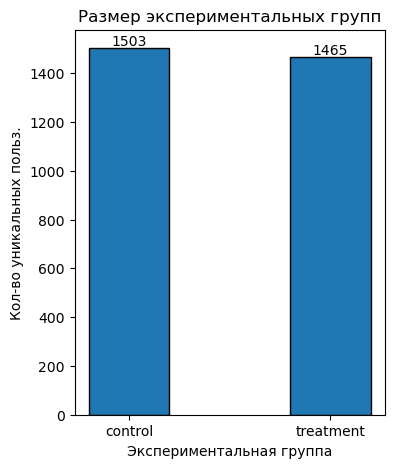

In [71]:
size_AB = users_AB.groupby('group')['user_id'].nunique()
print(f"Разница в количестве пользователей в группах А и В составила {round(abs(size_AB['control'] - size_AB['treatment'])/size_AB['control']*100, 2)} %")
size_AB = size_AB.sort_index()
plt.figure(figsize = (4,5))
bars = plt.bar(size_AB.index, size_AB, width = 0.4, edgecolor = 'k')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}', ha='center', va='bottom')
plt.title('Размер экспериментальных групп')
plt.xlabel('Экспериментальная группа')
plt.ylabel('Кол-во уникальных польз.')
plt.show()

Используем хи-квадрат критерий, чтобы проверить, отличается ли распределение характеристик (пол, регион, устройство, ОС) среди пользователей в разных выборках.  
H0: Распределение характеристики между двумя выборками не отличается.  
H1: Распределение характеристики между двумя выборками отличается.

region,Москва,Санкт-Петербург,Новосибирск,Московская область,Нижний Новгород,Краснодар,Ростов-на-Дону,Другие регионы,Екатеринбург
group,,,,,,,,,
control,371,230,65,115,65,63,39,487,68
treatment,359,220,50,120,59,46,45,494,72


Хи-квадрат тест p-value: 0.6996 > 0.05. Нет значимых различий в представленности регионов в тестовых группах.


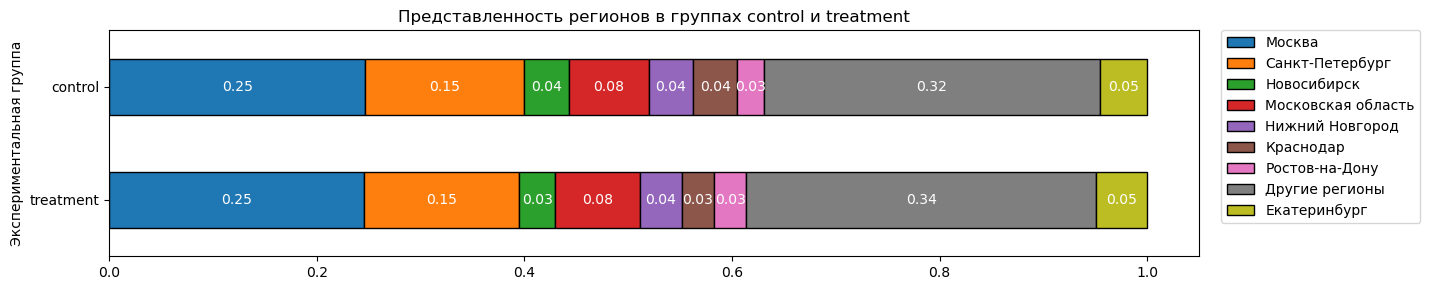

In [73]:
user_stat_test = users_AB[['user_id', 'gender', 'region', 'group']].drop_duplicates()
region_dstrb = user_stat_test.groupby('group')['region'].value_counts(normalize = True).unstack(fill_value = 0)
region_dstrb_v = user_stat_test.groupby('group')['region'].value_counts().unstack(fill_value = 0)

custom_order = ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Московская область', 
                'Нижний Новгород', 'Краснодар', 'Ростов-на-Дону', 'Другие регионы', 'Екатеринбург']
display(region_dstrb_v[custom_order]) 

#критерий хи квадрат: проверяем есть ли статистически значимое отличие в распределении регионов в группах А и B
table = [region_dstrb_v.loc['control'], region_dstrb_v.loc['treatment']]
chi2, p_value, _, _ = chi2_contingency(table)
if p_value > 0.05:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} > 0.05. Нет значимых различий в представленности регионов в тестовых группах.") 
else:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} <= 0.05. Есть значимые различия в представленности регионов в тестовых группах.") 

#график
region_dstrb = region_dstrb[custom_order].sort_index(ascending = False)
ax = region_dstrb.plot(kind = 'barh', stacked = True, edgecolor = 'k', figsize = (17,3))

plt.title('Представленность регионов в группах control и treatment')
plt.ylabel('Экспериментальная группа')
plt.legend(
    title='',
    loc='upper left',          
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.          
)

for i, (_, row) in enumerate(region_dstrb.iterrows()):
    x_offset = 0  # Начальное смещение для stacked bars
    for val in row:
        if val > 0:  # Пропускаем нулевые значения
            ax.text(x_offset + val/2, i, f"{val:.2f}", 
                    ha='center', va='center', color='white')
        x_offset += val

        
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

gender,F,M
group,,
control,745,758
treatment,766,699


Хи-квадрат тест p-value: 0.1485 > 0.05. Нет значимых различий в представленности регионов в тестовых группах.


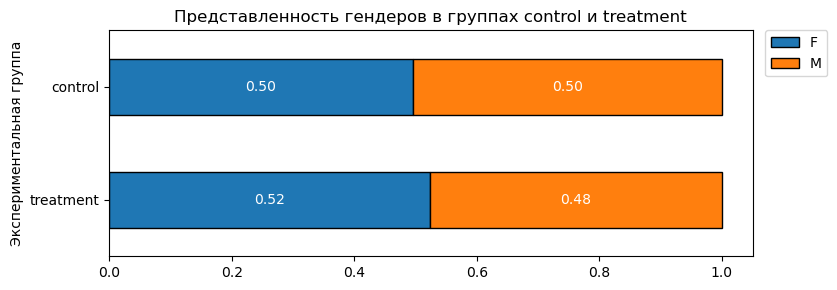

In [74]:
user_stat_test = users_AB[['user_id', 'gender', 'region', 'group']].drop_duplicates()
region_dstrb = user_stat_test.groupby('group')['gender'].value_counts(normalize = True).unstack(fill_value = 0)
region_dstrb_v = user_stat_test.groupby('group')['gender'].value_counts().unstack(fill_value = 0)

custom_order = ['F', 'M']
display(region_dstrb_v[custom_order]) 

#критерий хи квадрат: проверяем есть ли статистически значимое отличие в распределении регионов в группах А и B
table = [region_dstrb_v.loc['control'], region_dstrb_v.loc['treatment']]
chi2, p_value, _, _ = chi2_contingency(table)
if p_value > 0.05:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} > 0.05. Нет значимых различий в представленности регионов в тестовых группах.") 
else:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} <= 0.05. Есть значимые различия в представленности регионов в тестовых группах.") 

#график
region_dstrb = region_dstrb[custom_order].sort_index(ascending = False)
ax = region_dstrb.plot(kind = 'barh', stacked = True, edgecolor = 'k', figsize = (10,3))

plt.title('Представленность гендеров в группах control и treatment')
plt.ylabel('Экспериментальная группа')
plt.legend(
    title='',
    loc='upper left',          
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.          
)

for i, (_, row) in enumerate(region_dstrb.iterrows()):
    x_offset = 0  # Начальное смещение для stacked bars
    for val in row:
        if val > 0:  # Пропускаем нулевые значения
            ax.text(x_offset + val/2, i, f"{val:.2f}", 
                    ha='center', va='center', color='white')
        x_offset += val

        
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

os,Android,macOS,iOS,Windows
group,,,,
control,59,62,70,70
treatment,54,70,58,56


Хи-квадрат тест p-value: 0.5065 > 0.05. Нет значимых различий в представленности регионов в тестовых группах.


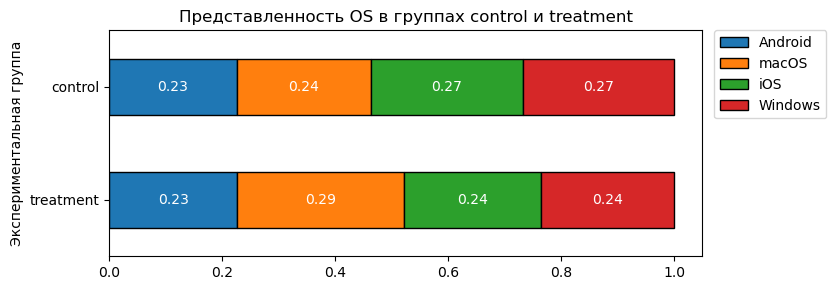

In [75]:
user_stat_test = events_AB[['user_id', 'device', 'os']].drop_duplicates()
user_stat_test = user_stat_test.merge(pa_marketplace_AB_split_users, how = 'inner', on = 'user_id' )
region_dstrb = user_stat_test.groupby('group')['os'].value_counts(normalize = True).unstack(fill_value = 0)
region_dstrb_v = user_stat_test.groupby('group')['os'].value_counts().unstack(fill_value = 0)

custom_order = ['Android', 'macOS', 'iOS', 'Windows']
display(region_dstrb_v[custom_order]) 

#критерий хи квадрат: проверяем есть ли статистически значимое отличие в распределении регионов в группах А и B
table = [region_dstrb_v.loc['control'], region_dstrb_v.loc['treatment']]
chi2, p_value, _, _ = chi2_contingency(table)
if p_value > 0.05:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} > 0.05. Нет значимых различий в представленности регионов в тестовых группах.") 
else:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} <= 0.05. Есть значимые различия в представленности регионов в тестовых группах.") 

#график
region_dstrb = region_dstrb[custom_order].sort_index(ascending = False)
ax = region_dstrb.plot(kind = 'barh', stacked = True, edgecolor = 'k', figsize = (10,3))

plt.title('Представленность OS в группах control и treatment')
plt.ylabel('Экспериментальная группа')
plt.legend(
    title='',
    loc='upper left',          
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.          
)

for i, (_, row) in enumerate(region_dstrb.iterrows()):
    x_offset = 0  # Начальное смещение для stacked bars
    for val in row:
        if val > 0:  # Пропускаем нулевые значения
            ax.text(x_offset + val/2, i, f"{val:.2f}", 
                    ha='center', va='center', color='white')
        x_offset += val

        
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

device,tablet,mobile,desktop
group,,,
control,96,85,80
treatment,89,60,89


Хи-квадрат тест p-value: 0.1351 > 0.05. Нет значимых различий в представленности регионов в тестовых группах.


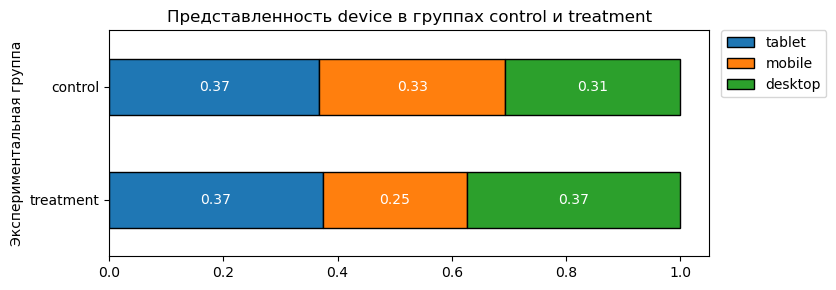

In [76]:
user_stat_test = events_AB[['user_id', 'device', 'os']].drop_duplicates()
user_stat_test = user_stat_test.merge(pa_marketplace_AB_split_users, how = 'inner', on = 'user_id' )
region_dstrb = user_stat_test.groupby('group')['device'].value_counts(normalize = True).unstack(fill_value = 0)
region_dstrb_v = user_stat_test.groupby('group')['device'].value_counts().unstack(fill_value = 0)

custom_order = ['tablet', 'mobile', 'desktop']

display(region_dstrb_v[custom_order]) 

#критерий хи квадрат: проверяем есть ли статистически значимое отличие в распределении регионов в группах А и B
table = [region_dstrb_v.loc['control'], region_dstrb_v.loc['treatment']]
chi2, p_value, _, _ = chi2_contingency(table)
if p_value > 0.05:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} > 0.05. Нет значимых различий в представленности регионов в тестовых группах.") 
else:
    print(f"Хи-квадрат тест p-value: {p_value:.4f} <= 0.05. Есть значимые различия в представленности регионов в тестовых группах.") 

#график
region_dstrb = region_dstrb[custom_order].sort_index(ascending = False)
ax = region_dstrb.plot(kind = 'barh', stacked = True, edgecolor = 'k', figsize = (10,3))

plt.title('Представленность device в группах control и treatment')
plt.ylabel('Экспериментальная группа')
plt.legend(
    title='',
    loc='upper left',          
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.          
)

for i, (_, row) in enumerate(region_dstrb.iterrows()):
    x_offset = 0  # Начальное смещение для stacked bars
    for val in row:
        if val > 0:  # Пропускаем нулевые значения
            ax.text(x_offset + val/2, i, f"{val:.2f}", 
                    ha='center', va='center', color='white')
        x_offset += val

        
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### Выводы о независимости и сопоставимости экспериментальных групп

Данные содержат информацию о действиях и покупках 2968 пользователей. Контрольная экспериментальная группа состояла из 1503 человек, экспериментальная  - 1465 пользователей. Разница в количестве пользователей в двух группах составила менее 3%, что является допустимым при проведении A/B- теста.

Пользователи, которые попали в две экспериментальные группы отсутствуют. Группы сопоставимы и не имеют статистически значимых отличий в распределении устройств, OS, гендеров или регионов. А/B - тест проведен корректно.

Сравниваем воронки событий в двух группах:

### Сравнение воронок событий между экспериментальными группами

In [80]:
orders_AB_events = orders_AB[['user_id', 'order_id','group']].drop_duplicates().copy()
orders_AB_events['event_type'] = 'order'
orders_AB_events = orders_AB_events.rename(columns = {'order_id':'event_id'})

In [81]:
funnel_eventsAB = events_AB[events_AB['event_type'].isin(funnel_steps)][['user_id', 'event_id','event_type', 'group']]
funnel_eventsAB = pd.concat([funnel_eventsAB, orders_AB_events[['user_id', 'event_id', 'event_type', 'group']]])

In [82]:
df_funnel_control = funnel_eventsAB[(funnel_eventsAB['event_type'].isin(funnel_steps_complete))&(funnel_eventsAB['group'] == 'control')]
df_funnel_control = df_funnel_control.groupby('event_type')['user_id'].nunique().reindex(funnel_steps_complete).reset_index()
df_funnel_control['CR'] = (df_funnel_control['user_id']/df_funnel_control['user_id'].iloc[0]*100).round(1)
df_funnel_control['CR_prev_step'] = (df_funnel_control['user_id']/df_funnel_control['user_id'].shift(1)*100).round(1)

df_funnel_test = funnel_eventsAB[(funnel_eventsAB['event_type'].isin(funnel_steps_complete))&(funnel_eventsAB['group'] == 'treatment')]
df_funnel_test = df_funnel_test.groupby('event_type')['user_id'].nunique().reindex(funnel_steps_complete).reset_index()
df_funnel_test['CR'] = (df_funnel_test['user_id']/df_funnel_test['user_id'].iloc[0]*100).round(1)
df_funnel_test['CR_prev_step'] = (df_funnel_test['user_id']/df_funnel_test['user_id'].shift(1)*100).round(1)

print(df_funnel_control)
print(df_funnel_test)

          event_type  user_id     CR  CR_prev_step
0          page_view      258  100.0           NaN
1       product_view      257   99.6          99.6
2      product_click      245   95.0          95.3
3        add_to_cart      211   81.8          86.1
4     checkout_start      126   48.8          59.7
5  checkout_complete       79   30.6          62.7
6              order       16    6.2          20.3
          event_type  user_id     CR  CR_prev_step
0          page_view      232  100.0           NaN
1       product_view      230   99.1          99.1
2      product_click      225   97.0          97.8
3        add_to_cart      193   83.2          85.8
4     checkout_start      128   55.2          66.3
5  checkout_complete       85   36.6          66.4
6              order      110   47.4         129.4


Возможно, что для пользователей из тестовой группы можно было сделать переход от шага checkout_start к order минуя шаг "checkout_complete". Таким образом можно объяснить значение step-by-step конверсии в orders = 129.(или, возможно, в реальные данные подмешаны ошибочные успешные заказы) 

### Сравнение ключевых метрик между экспериментальными группами
**Основная метрика**  
Конверсия в первую покупку — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе

In [85]:
users_AB['payer_flag'] = users_AB['user_id'].isin(orders_AB['user_id'].unique()).astype(int)
CR_reg_order = users_AB.groupby('group').agg(
users = ('user_id', 'nunique'),
payers = ('payer_flag', 'sum')).reset_index()
CR_reg_order['CR'] = round(CR_reg_order['payers']/CR_reg_order['users']*100,2)
print(CR_reg_order)

       group  users  payers    CR
0    control   1503      16  1.06
1  treatment   1465     110  7.51


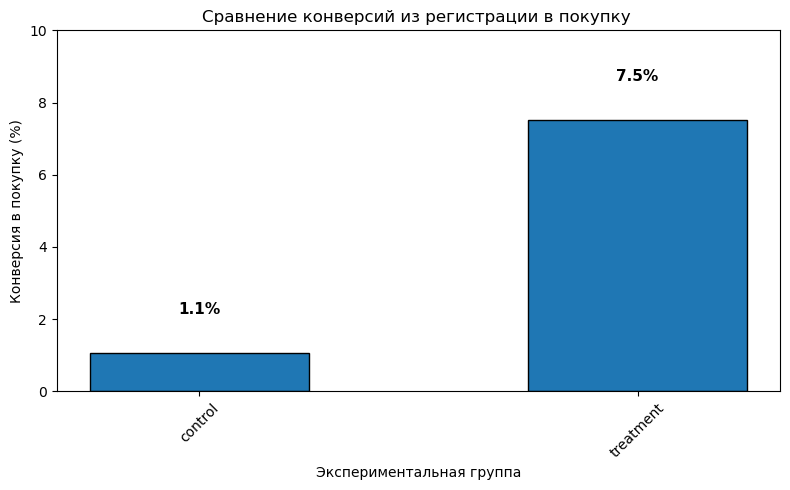

In [86]:
plt.figure(figsize=(8, 5))
bars = plt.bar(CR_reg_order['group'], CR_reg_order['CR'], width=0.5, edgecolor='k')

plt.title('Сравнение конверсий из регистрации в покупку ')
plt.xlabel('Экспериментальная группа')
plt.ylim(0,10)
plt.ylabel('Конверсия в покупку (%)')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [87]:
alpha = 0.05 
print()
print(f'--- Анализ конверсии из зарегистрированного пользователя  в покупателя')
print('H0: конверсии в контрольной группе и тестовой группе не отличаются.')
print('H1: конверсии в контрольной группе и тестовой группе отличаются.')
print()
p_a = (CR_reg_order[CR_reg_order['group'] == 'control']['CR'].iloc[0])/100
p_b = (CR_reg_order[CR_reg_order['group'] == 'treatment']['CR'].iloc[0])/100
print(f'Конверсия в контрольной группе: {round(p_a*100,2)}%')
print(f'Конверсия в тестовой группе: {round(p_b*100,2)}%')
print(f'Разница в конверсии среди пользователей: {round(abs(p_a - p_b)*100,2)}%')

n_a = CR_reg_order[CR_reg_order['group'] == 'control']['users'].iloc[0]
m_a = CR_reg_order[CR_reg_order['group'] == 'control']['payers'].iloc[0]

n_b = CR_reg_order[CR_reg_order['group'] == 'treatment']['users'].iloc[0]
m_b = CR_reg_order[CR_reg_order['group'] == 'treatment']['users'].iloc[0]
#Проверяем предпосылку о достаточном количестве данных для Z-теста

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
stat_ztest, p_value_ztest = proportions_ztest(
        [m_a, m_b],
        [n_a, n_b],
        alternative='two-sided' 
)
    
if p_value_ztest > alpha:
    print(f'pvalue={round(p_value_ztest,3)} > {round(alpha,3)}')
    print(f'Нулевая гипотеза не отвергается. Значимого отличия между выборками нет.')
else:
    print(f'pvalue={round(p_value_ztest,3)} < {round(alpha,3)}')
    print(f'Нулевая гипотеза отвергается. Отличие конверсий статистически значимо.')


--- Анализ конверсии из зарегистрированного пользователя  в покупателя
H0: конверсии в контрольной группе и тестовой группе не отличаются.
H1: конверсии в контрольной группе и тестовой группе отличаются.

Конверсия в контрольной группе: 1.06%
Конверсия в тестовой группе: 7.51%
Разница в конверсии среди пользователей: 6.45%
Предпосылка о достаточном количестве данных выполняется!
pvalue=0.0 < 0.05
Нулевая гипотеза отвергается. Отличие конверсий статистически значимо.


**Вспомогательные метрики:**  
- ARPU (средняя выручка на пользователя TikTok)
- ARPPU (средняя выручка на покупателя TikTok)
- AOV (средний чек TikTok)

In [89]:
amount_ab = orders_AB.groupby('group')['total_price'].sum()
group_users = users_AB.groupby('group')['user_id'].nunique()
ARPU = (amount_ab*0.05/group_users)
ARPU_abs = ARPU.loc['treatment'] - ARPU.loc['control']
ARPU_rel = (ARPU.loc['treatment'] - ARPU.loc['control']) / ARPU.loc['control']*100
print('ARPU. Средняя выручка на одного пользователя TikTok:')
print(ARPU)
print('---')
print('Абсолютная разница:', round(ARPU_abs, 2))
print('Относительная разница:', round(ARPU_rel, 2),'%')

ARPU. Средняя выручка на одного пользователя TikTok:
group
control       12.587255
treatment    131.249045
dtype: float64
---
Абсолютная разница: 118.66
Относительная разница: 942.71 %


In [90]:
amount_ab = orders_AB.groupby('group')['total_price'].sum()
group_payers = users_AB[users_AB['payer_flag'] == 1].groupby('group')['user_id'].nunique()
ARPPU = (amount_ab*0.05/group_payers)
ARPPU_abs = ARPPU.loc['treatment'] - ARPPU.loc['control']
ARPPU_rel = (ARPPU.loc['treatment'] - ARPPU.loc['control']) / ARPPU.loc['control']*100
print('ARPPU. Средняя выручка на платящего пользователя TikTok:')
print(ARPPU)
print('---')
print('Абсолютная разница:', round(ARPPU_abs, 2))
print('Относительная разница:', round(ARPPU_rel, 2),'%')

ARPPU. Средняя выручка на платящего пользователя TikTok:
group
control      1182.415313
treatment    1747.998650
dtype: float64
---
Абсолютная разница: 565.58
Относительная разница: 47.83 %


In [91]:
price_count = orders_AB.groupby('group')['total_price'].sum()
orders_count = orders_AB.groupby('group')['order_id'].nunique()
aov = price_count/orders_count
aov_abs = aov.loc['treatment'] - aov.loc['control']
aov_rel = (aov.loc['treatment'] - aov.loc['control']) / aov.loc['control']*100
print('AOV. Средний чек пользователя TikTok:')
print(aov)
print('---')
print('Абсолютная разница:', round(aov_abs, 2))
print('Относительная разница:', round(aov_rel, 2),'%')

AOV. Средний чек пользователя TikTok:
group
control      15765.53750
treatment    16647.60619
dtype: float64
---
Абсолютная разница: 882.07
Относительная разница: 5.59 %


**Барьерная метрика:** общая выручка от пользователей TikTok


In [93]:
revenue = orders_AB.groupby('group')['total_price'].sum()
revenue = revenue*0.05
revenue_abs = revenue.loc['treatment'] - revenue.loc['control']
revenue_rel = (revenue.loc['treatment'] - revenue.loc['control']) / revenue.loc['control']*100
print('Барьерная метрика. Общая выручка от пользователей TikTok:')
print(revenue)
print('---')
print('Абсолютная разница:', round(revenue_abs, 2))
print('Относительная разница:', round(revenue_rel, 2),'%')

Барьерная метрика. Общая выручка от пользователей TikTok:
group
control       18918.6450
treatment    192279.8515
Name: total_price, dtype: float64
---
Абсолютная разница: 173361.21
Относительная разница: 916.35 %


## Выводы по результатам А/В эксперимента

В тесте участвовали 2968 пользователей, контрольная экспериментальная группа состояла из 1503 человек, экспериментальная  - 1465 пользователей. Пользователи на группы были разделены корректно, группы пользователей не пересекаются между собой, характеристики групп одинаково представлены в обеих группах. Значимых отличий в составе групп нет.

В экспериментальной группе конверсия из регистрации в покупку составила 7.5%, в контрольной группе 1.1%. Различие в конверсиях между двумя группами статистически значимо (p-value < 0.05). 

Вспомогательный метрики также выросли для экспериментальной группы. Средняя выручка на пользователя (ARPU) в экспериментальной группе выросла почти  в 10 раз, средняя выручка на платящего пользователя выросла на 47.8%. Средний чек в экспериментальной группе составил 16647.6, в контрольной -  15765.5.

Барьерная метрика не имеет негативных изменений: общая выручка от пользователей TikTok экспериментальной группы выросла почти в 10 раз.
При условии, если полученные изменения конверсии окупают маркетинговые вложения в бонусы для первой покупки, внедрение этой программы рекомендуется.